# Delivery Cost Analysis

This notebook analyzes food delivery order data to understand how different commission structures impact platform and merchant profitability.

Key focus:
- Platform vs Merchant profit structure
- Commission rate simulation
- Profit optimization scenarios

# **1. Imports & Functions**

In [1]:
# ▶ Warnings 제거
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# ▶ Google drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 27.1 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib as mpl

# fm.fontManager('NanumGothic.ttf')
# plt.rcParams['font.family'] = 'NanumGothic'

In [5]:
os.chdir('/content/drive/MyDrive/제로베이스_부트캠프/팀프로젝트')
os.getcwd()

'/content/drive/MyDrive/제로베이스_부트캠프/팀프로젝트'

# **2. Data Loading & Preprocessing**

In [ ]:
df = pd.read_csv('food_orders_new_delhi.csv')
df.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0


In [31]:
# 'Discounts and Offers' Null check
df['Discounts and Offers'] = df['Discounts and Offers'].fillna(0)


# 'Discounts and Offers' Preprocessing
def calculate_discount_amount(row):
    offer = str(row['Discounts and Offers']).lower()
    order_val = row['Order Value']

    if '%' in offer:
        try:
            pct = float(''.join(filter(str.isdigit, offer))) / 100
            return order_val * pct
        except:
            return 0.0
    elif 'off' in offer:
        try:
            # if '50 off', apply 50 Rupee discounts always
            amount = float(''.join(filter(str.isdigit, offer)))
            return amount
        except:
            return 0.0
    return 0.0

# Apply
df['Discount Cost'] = df.apply(calculate_discount_amount, axis=1)

In [32]:
df['Real Order Value'] = df['Order Value'] - df['Discount Cost']
df['Discount Cost Platform'] = df['Discount Cost']   # platform 100% covered
df['Discount Cost Merchant'] = 0                     # Merchant 0%
df['Delivery Fee Platform'] = 0                      # Platform 0%
df['Delivery Fee Merchant'] = df['Delivery Fee']     # Merchant 100% covered

# Profit Calculation
df['Platform Profit'] = df['Commission Fee'] - df['Discount Cost Platform'] - df['Delivery Fee Platform']
df['Merchant Profit'] = df['Real Order Value'] - df['Commission Fee'] - df['Payment Processing Fee'] - df['Delivery Fee Merchant']

# Profit Share Calculation
df['Platform Share'] = df['Platform Profit'] / df['Real Order Value']
df['Merchant Share'] = df['Merchant Profit'] / df['Real Order Value']

# Commission Rate Calculation
df['Commission Rate'] = round(df['Commission Fee'] / df['Real Order Value'], 3)

In [33]:
df = df[~(df['Commission Rate']>1)].copy()
print(df['Platform Profit'].sum() / df['Real Order Value'].sum())
print(df['Merchant Profit'].sum() / df['Real Order Value'].sum())

0.04996401091732856
0.8164805160918954


# **3. EDA**

## Distribution of Platform vs. Store Revenue

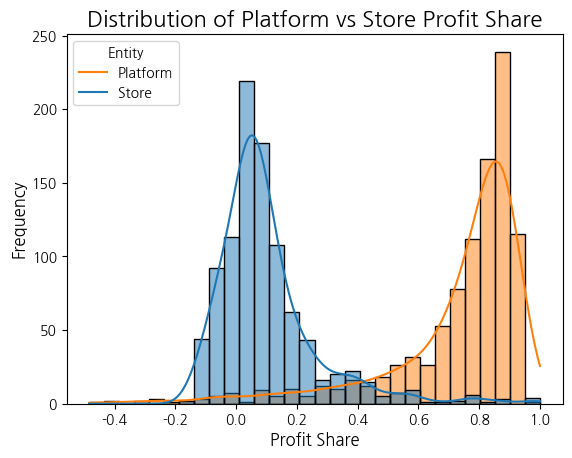

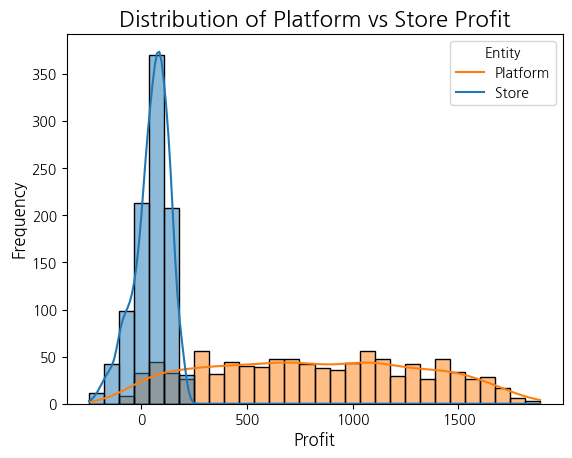

In [34]:
# melt로 데이터프레임 변환
df_melt_share = df.melt(value_vars=['Platform Share', 'Merchant Share'],
                  var_name='Entity', value_name='Profit Share')

df_melt_profit = df.melt(value_vars=['Platform Profit', 'Merchant Profit'],
                  var_name='Entity', value_name='Profit')

# Visualize profit share distribution (KDE + Histogram)
sns.histplot(data=df_melt_share, x='Profit Share', hue='Entity',
             bins=30, kde=True, alpha=0.5)

plt.title("Distribution of Platform vs Store Profit Share", fontsize=16)
plt.xlabel("Profit Share", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title='Entity', labels=['Platform', 'Store'])
plt.show();

sns.histplot(data=df_melt_profit, x='Profit', hue='Entity',
             bins=30, kde=True, alpha=0.5)

plt.title("Distribution of Platform vs Store Profit", fontsize=16)
plt.xlabel("Profit", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title='Entity', labels=['Platform', 'Store'])
plt.show()


## The distribution of platform and store profits appears to reflect a well-structured commission fee system.
## However, since this reflects the overall distribution, we will use a pairplot to further examine the relationships between variables.

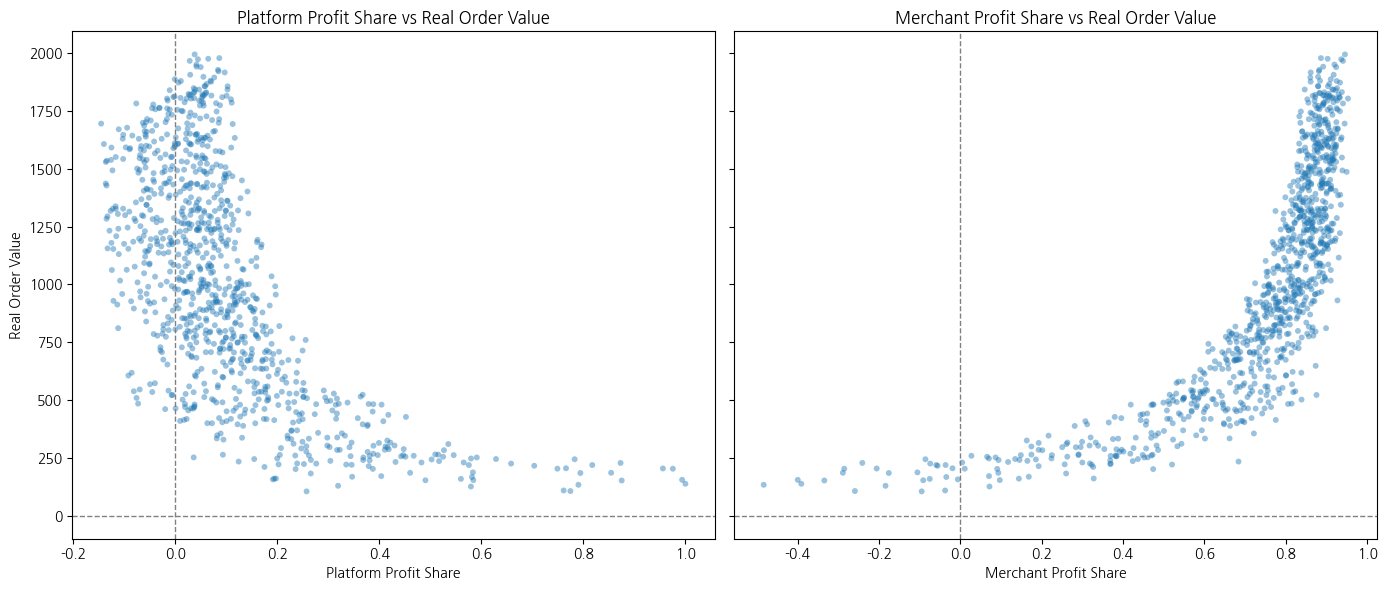

In [35]:
## Scatter plots: Real Order Value vs Platform / Merchant Profit Share

fig, axs = plt.subplots(1, 2, figsize=(14,6), sharex=False, sharey=True)

# Platform
sns.scatterplot(data=df, x='Platform Share', y='Real Order Value',
                ax=axs[0], s=18, alpha=0.45, edgecolor='none')
axs[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axs[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[0].set_title('Platform Profit Share vs Real Order Value')
axs[0].set_xlabel('Platform Profit Share')
axs[0].set_ylabel('Real Order Value')

# Merchant
sns.scatterplot(data=df, x='Merchant Share', y='Real Order Value',
                ax=axs[1], s=18, alpha=0.45, edgecolor='none')
axs[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axs[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[1].set_title('Merchant Profit Share vs Real Order Value')
axs[1].set_xlabel('Merchant Profit Share')
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

## When Real Order Value is high, the platform profit appears to be lower,
## while when it is low, the platform profit is even lower. This result seems counterintuitive.
## Instead of a negative correlation, Real Order Value and Platform profit share
## would generally be expected to show a positive relationship.

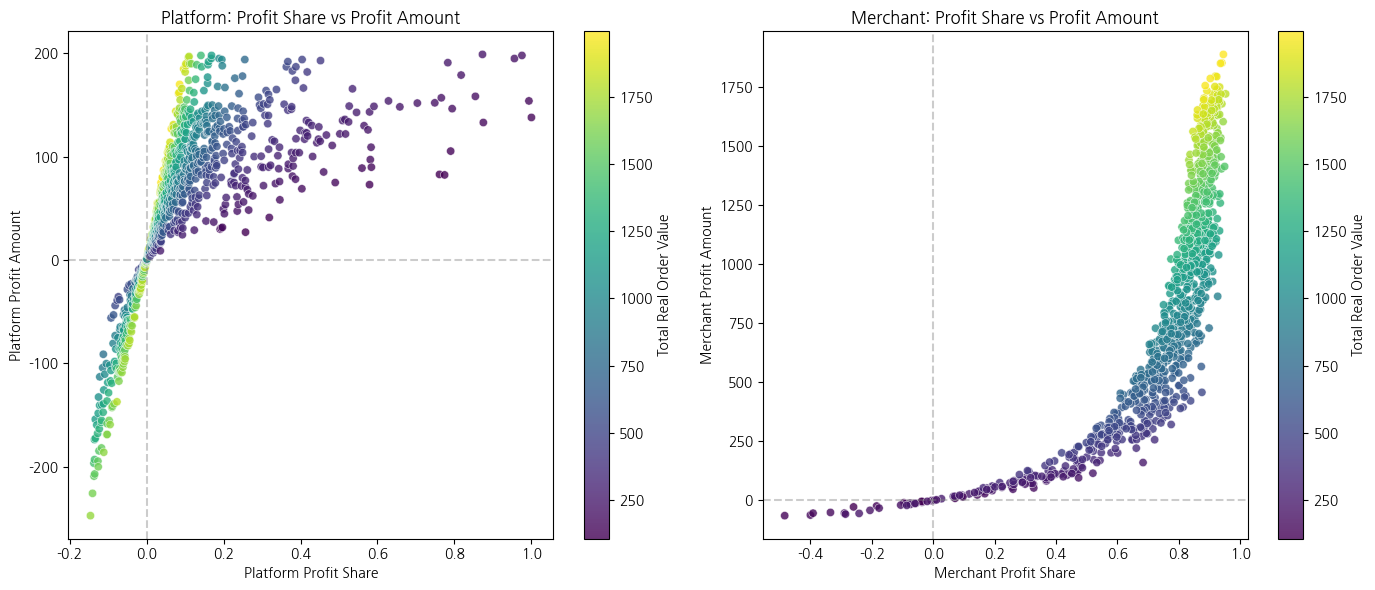

In [36]:
# Relationship between platform/merchant profit share, profit amount, and Real Order Value
d = df.copy()

g = (d.assign(px=lambda x: x['Platform Share'],
              mx=lambda x: x['Merchant Share'],
              pp=lambda x: (x['Platform Profit']),
              mp=lambda x: (x['Merchant Profit']))
      .groupby(['px','pp','mx','mp'], as_index=False)
      .agg(order_value_sum=('Real Order Value', 'sum'))  # Sum of order values
)

fig, axs = plt.subplots(1, 2, figsize=(14,6))

# (1) Platform perspective
sc1 = axs[0].scatter(g['px'], g['pp'], c=g['order_value_sum'],
                     cmap='viridis', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[0].set_title('Platform: Profit Share vs Profit Amount')
axs[0].set_xlabel('Platform Profit Share')
axs[0].set_ylabel('Platform Profit Amount')
fig.colorbar(sc1, ax=axs[0], label='Total Real Order Value')

# (2) Merchant perspective
sc2 = axs[1].scatter(g['mx'], g['mp'], c=g['order_value_sum'],
                     cmap='viridis', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[1].set_title('Merchant: Profit Share vs Profit Amount')
axs[1].set_xlabel('Merchant Profit Share')
axs[1].set_ylabel('Merchant Profit Amount')
fig.colorbar(sc2, ax=axs[1], label='Total Real Order Value')

for ax in axs:
    ax.axhline(0, ls='--', c='gray', alpha=0.4)
    ax.axvline(0, ls='--', c='gray', alpha=0.4)

plt.tight_layout(); plt.show()

## As order value increases, the platform profit share generally decreases, and in some cases even becomes negative.
## There are more cases where both the platform’s profit amount and profit share are negative compared to those of merchants.
## Although there are balanced regions where both sides generate profit,
## profit imbalance becomes particularly pronounced in high-value orders,
## suggesting that a strategic restructuring of the revenue model may be needed.

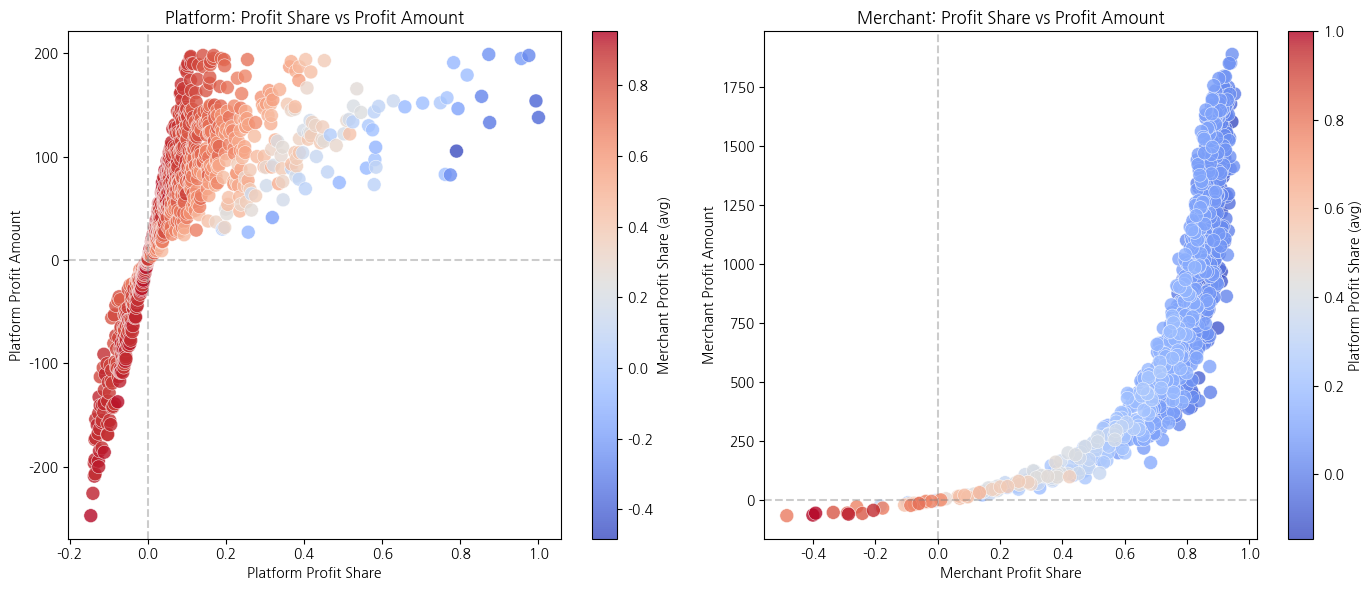

In [37]:
## Relationship between Platform/Merchant Profit Share and Profit Amount
d = df.copy()

# Grid for frequency aggregation (bubble size)
g = (d.assign(px=lambda x: x['Platform Share'],
              mx=lambda x: x['Merchant Share'],
              pp=lambda x: (x['Platform Profit']),
              mp=lambda x: (x['Merchant Profit']))
      .groupby(['px','pp','mx','mp'], as_index=False)
      .size()
      .rename(columns={'size':'count'}))

# Bubble size scaling
sizes = (np.sqrt(g['count'] / g['count'].max()) * 100).clip(20, None)

fig, axs = plt.subplots(1, 2, figsize=(14,6))

# (1) Platform perspective
sc1 = axs[0].scatter(g['px'], g['pp'], s=sizes, c=g['mx'],
                     cmap='coolwarm', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[0].set_title('Platform: Profit Share vs Profit Amount')
axs[0].set_xlabel('Platform Profit Share')
axs[0].set_ylabel('Platform Profit Amount')
fig.colorbar(sc1, ax=axs[0], label='Merchant Profit Share (avg)')

# (2) Merchant perspective
sc2 = axs[1].scatter(g['mx'], g['mp'], s=sizes, c=g['px'],
                     cmap='coolwarm', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[1].set_title('Merchant: Profit Share vs Profit Amount')
axs[1].set_xlabel('Merchant Profit Share')
axs[1].set_ylabel('Merchant Profit Amount')
fig.colorbar(sc2, ax=axs[1], label='Platform Profit Share (avg)')

for ax in axs:
    ax.axhline(0, ls='--', c='gray', alpha=0.4)
    ax.axvline(0, ls='--', c='gray', alpha=0.4)

plt.tight_layout(); plt.show()

1. **Left) As the platform profit share increases, the merchant profit share decreases.**
- When the platform share exceeds roughly 0.6, the merchant profit share often becomes negative.
- However, in the third quadrant, some transactions show both low profit share and low profit amount, indicating potential inefficiencies and the need for profit improvement (e.g., adjusting the commission rate).

2. **Right) When the merchant profit share exceeds 0.8, the platform profit share frequently becomes negative.**
- Although there are regions where both the platform and merchants achieve high profit amounts,
- there are also many transactions where the platform loses both in profit amount and profit share,
- suggesting that structural adjustments to the revenue model may be necessary.

In [38]:
# 플랫폼, 업주 모두 수익 및 수익률이 음수 인 경우만 추출
df_minus_platform = df[(df['Platform Profit'] < 0) | (df['Platform Share'] < 0)]
df_minus_merchant = df[(df['Merchant Profit'] < 0) | (df['Merchant Share'] < 0)]

In [39]:
df_minus_platform.groupby('Discounts and Offers').count()
## As expected, the 15% discount results in significant losses.
## However, this promotion targets new users, so the loss may be strategically acceptable.
## This raises an important question: why do losses still occur under other discount levels?

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Commission Fee,Payment Processing Fee,...,Real Order Value,Discount Cost Platform,Discount Cost Merchant,Delivery Fee Platform,Delivery Fee Merchant,Platform Profit,Merchant Profit,Platform Share,Merchant Share,Commission Rate
Discounts and Offers,,,,,,,,,,,,,,,,,,,,,
10%,91,91,91,91,91,91,91,91,91,91,...,91,91,91,91,91,91,91,91,91,91
15% New User,117,117,117,117,117,117,117,117,117,117,...,117,117,117,117,117,117,117,117,117,117
5% on App,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17


In [40]:
df_minus_platform[~(df_minus_platform['Discounts and Offers'] == "15% New User")][['Real Order Value', 'Commission Fee']].agg(['mean', 'median'])
## The commission fee appears significantly lower relative to the order value.
## Further analysis is needed to determine whether other factors—such as time of day,
## delivery time, or payment method—also contribute to the observed differences.

,Real Order Value,Commission Fee
mean,1419.511111,96.009259
median,1482.750000,89.500000


In [41]:
df_minus_merchant[['Real Order Value', 'Commission Fee']].agg(['mean', 'median'])

,Real Order Value,Commission Fee
mean,174.354167,145.583333
median,175.850000,152.000000


* In cases where merchants experience losses, the commission fee is often nearly as large as the order value. This indicates that **the current commission fee structure may require redefinition or adjustment**

# **4. Simulation**

## 01. Optimal Commission Rate Simulation

In [42]:
df_cm_rate = df.copy()


def sweep_commission_by_segment_auto(df_cm_rate,
                                     segments=[(0,35),(35,65),(65,100)],
                                     rate_range=(8,24),
                                     combo_width=3,
                                     objective="platform_total_profit",
                                     platform_min_avg_margin=0.1,
                                     merchant_min_avg_margin=0.68):

    # 1) 가게별 총매출 + 퍼센타일
    sales = (df_cm_rate.groupby('Restaurant ID', as_index=False)['Real Order Value']
               .sum()
               .rename(columns={'Real Order Value':'total_sales'}))

    sales['pct'] = sales['total_sales'].rank(ascending=False, pct=True) * 100
    results = []

    # 2) 연속된 수수료 조합만 생성 (상위 구간 수수료 낮게)
    for base_rate in range(rate_range[0], rate_range[1]-combo_width+2):
        # 구간별 수수료: 상위 구간이 낮고, 하위 구간이 높도록
        comb = [base_rate + i for i in range(combo_width)]

        # 3) 각 구간에 맞는 수수료율 적용
        def assign_rate(pct):
            for i, (low, high) in enumerate(segments):
                if low < pct <= high:
                    return comb[i]
            return comb[-1]

        sales['fee_rate'] = sales['pct'].apply(assign_rate)

        # 4) df_cm_rate과 병합
        temp_df = df_cm_rate.merge(sales[['Restaurant ID','fee_rate']], on='Restaurant ID', how='left')

        # 5) 수익 계산
        temp_df['commission'] = (temp_df['Order Value'] - temp_df['Discount Cost Merchant']) * temp_df['fee_rate'] / 100
        platform_profit_each = temp_df['commission'] - temp_df['Discount Cost Platform'] - temp_df['Delivery Fee Platform']
        merchant_profit_each = temp_df['Real Order Value'] - temp_df['commission'] - temp_df['Discount Cost Merchant'] - temp_df['Delivery Fee Merchant'] - temp_df['Payment Processing Fee'] - temp_df['Refunds/Chargebacks']

        denom = np.where(temp_df['Real Order Value']==0, np.nan, temp_df['Real Order Value'])
        platform_avg_margin = np.nanmean(platform_profit_each / denom)
        merchant_avg_margin = np.nanmean(merchant_profit_each / denom)

        # 6) 제약조건 확인
        if platform_avg_margin >= platform_min_avg_margin and merchant_avg_margin >= merchant_min_avg_margin:
            results.append({
                "best combination": comb,
                "platform_total_profit": platform_profit_each.sum(),
                "merchant_total_profit": merchant_profit_each.sum(),
                "platform_avg_margin": platform_avg_margin,
                "merchant_avg_margin": merchant_avg_margin
            })

    if not results:
        print("No combination to meet conditions")
        return None, None

    res_df = pd.DataFrame(results)

    # 7) 목적함수 기준 최적 조합 선택
    best_row = res_df.sort_values(objective, ascending=False).iloc[0]

    return res_df, best_row

# ---- 실행 예시 ----
res_df, best_row = sweep_commission_by_segment_auto(df_cm_rate)

# Results
if res_df is not None:
    print("Details:")
    print(best_row)


Details:
best combination         [17, 18, 19]
platform_total_profit       110743.98
merchant_total_profit       707448.52
platform_avg_margin          0.108665
merchant_avg_margin          0.680126
Name: 0, dtype: object


In [43]:
df_sim = df.copy()

# 원본 병합 + 건별 수수료금액
df_sim = df_sim.merge(sales[['Restaurant ID', 'fee_rate']], on='Restaurant ID', how='left')


In [44]:
df_sim['Discount Cost Platform'] = df_sim['Discount Cost']  # Platform 100% Covered
df_sim['Discount Cost Merchant'] = 0                     # Merchant 0%
df_sim['Delivery Fee Platform'] = 0                      # Platform 0%
df_sim['Delivery Fee Merchant'] = df_sim['Delivery Fee']     # Merchant 100% Covered
df_sim['Commission Fee'] = round((df_sim['Order Value'] - df['Discount Cost Merchant']) * df_sim['fee_rate'],2)

# 플랫폼/업주 수익 계산
df_sim['Platform Profit'] = df_sim['Commission Fee'] - df_sim['Discount Cost Platform'] - df_sim['Delivery Fee Platform']
df_sim['Merchant Profit'] = df_sim['Real Order Value'] - df_sim['Commission Fee'] - df_sim['Payment Processing Fee'] - df_sim['Delivery Fee Merchant'] - df_sim['Discount Cost Merchant'] - df_sim['Refunds/Chargebacks']

# 수익률 계산
df_sim['Platform Share'] = df_sim['Platform Profit'] / df_sim['Real Order Value']
df_sim['Merchant Share'] = df_sim['Merchant Profit'] / df_sim['Real Order Value']

In [45]:
# 전체적인 Platform 수익률 및 Merchant 수익률 확인
df_sim['Platform_change'] = df_sim['Platform Share'] - df['Platform Share']
df_sim['Merchant_change'] = df_sim['Merchant Share'] - df['Merchant Share']

summary_table = pd.DataFrame({
'Original_Platform_Avg_Profit_Share': [df['Platform Share'].mean()],
'Simulated_Platform_Avg_Profit_Share': [df_sim['Platform Share'].mean()],
'Platform_Profit_Share_Change_Avg': [df_sim['Platform_change'].mean()],
'Original_Merchant_Avg_Profit_Share': [df['Merchant Share'].mean()],
'Simulated_Merchant_Avg_Profit_Share': [df_sim['Merchant Share'].mean()],
'Merchant_Profit_Share_Change_Avg': [df_sim['Merchant_change'].mean()],
})
summary_table

,Original_Platform_Avg_Profit_Share,Simulated_Platform_Avg_Profit_Share,Platform_Profit_Share_Change_Avg,Original_Merchant_Avg_Profit_Share,Simulated_Merchant_Avg_Profit_Share,Merchant_Profit_Share_Change_Avg
0,0.101116,0.11449,0.011563,0.729933,0.673821,-0.053968


* Platform + 1.1%p, Merchant -1.1%p

## 02. Evaluation of Commission Rate Suitability

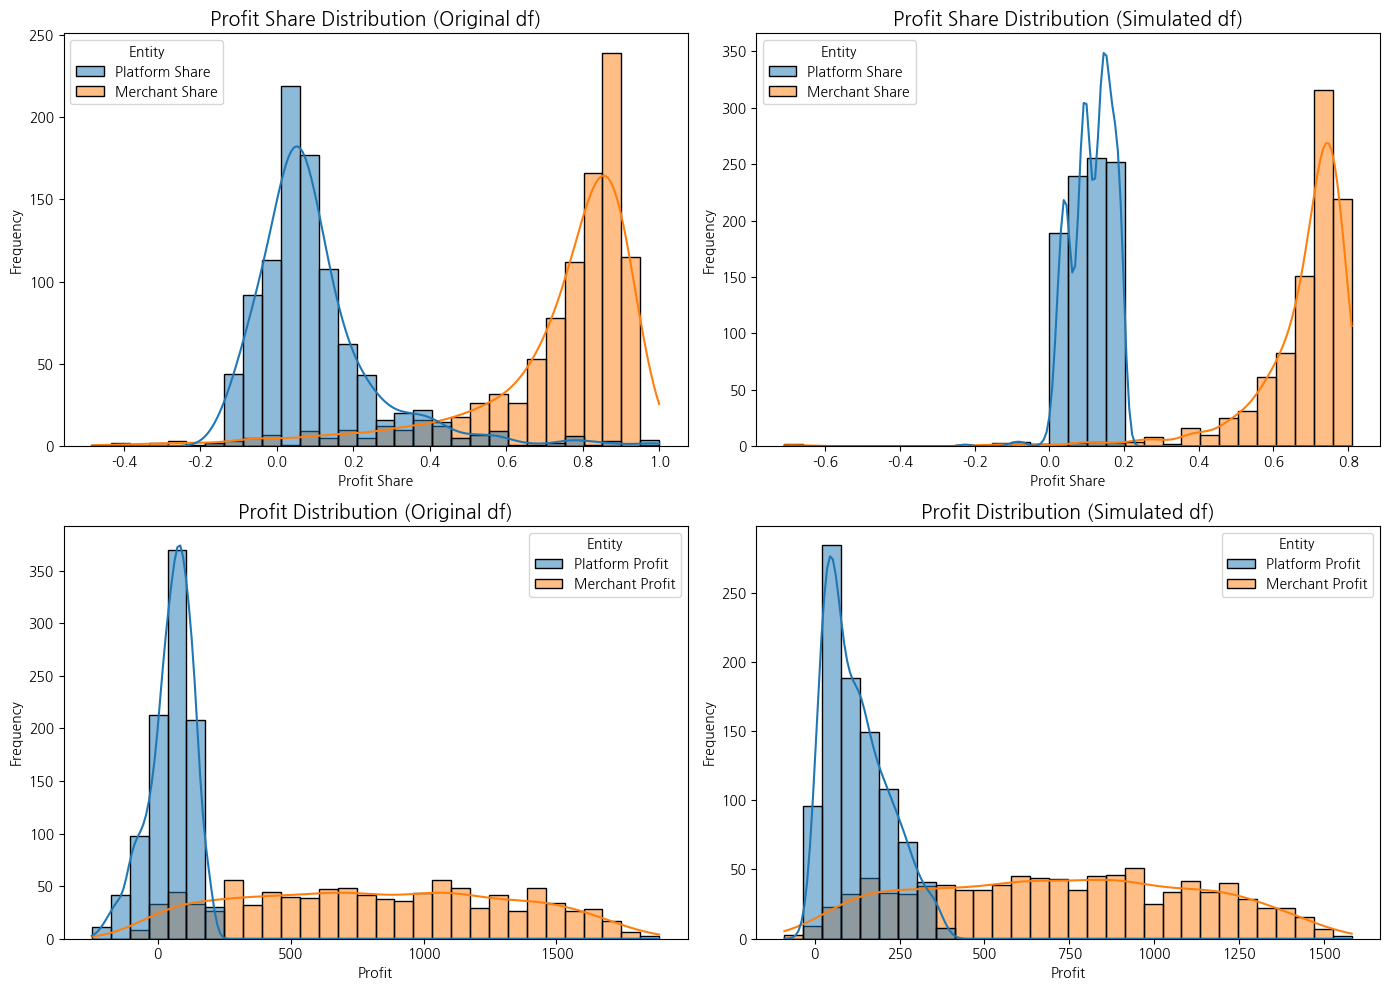

In [46]:
# Melt transformation
df_melt_share_old = df.melt(value_vars=['Platform Share', 'Merchant Share'],
                            var_name='Entity', value_name='Profit Share')

df_melt_profit_old = df.melt(value_vars=['Platform Profit', 'Merchant Profit'],
                             var_name='Entity', value_name='Profit')

df_melt_share_new = df_sim.melt(value_vars=['Platform Share', 'Merchant Share'],
                                var_name='Entity', value_name='Profit Share')

df_melt_profit_new = df_sim.melt(value_vars=['Platform Profit', 'Merchant Profit'],
                                 var_name='Entity', value_name='Profit')

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1) Profit share distribution for df
sns.histplot(data=df_melt_share_old, x='Profit Share', hue='Entity',
             bins=30, kde=True, alpha=0.5, ax=axes[0,0])
axes[0,0].set_title("Profit Share Distribution (Original df)", fontsize=14)
axes[0,0].set_xlabel("Profit Share")
axes[0,0].set_ylabel("Frequency")

# 2) Profit distribution for df
sns.histplot(data=df_melt_profit_old, x='Profit', hue='Entity',
             bins=30, kde=True, alpha=0.5, ax=axes[1,0])
axes[1,0].set_title("Profit Distribution (Original df)", fontsize=14)
axes[1,0].set_xlabel("Profit")
axes[1,0].set_ylabel("Frequency")

# 3) Profit share distribution for df_sim
sns.histplot(data=df_melt_share_new, x='Profit Share', hue='Entity',
             bins=30, kde=True, alpha=0.5, ax=axes[0,1])
axes[0,1].set_title("Profit Share Distribution (Simulated df)", fontsize=14)
axes[0,1].set_xlabel("Profit Share")
axes[0,1].set_ylabel("Frequency")

# 4) Profit distribution for df_sim
sns.histplot(data=df_melt_profit_new, x='Profit', hue='Entity',
             bins=30, kde=True, alpha=0.5, ax=axes[1,1])
axes[1,1].set_title("Profit Distribution (Simulated df)", fontsize=14)
axes[1,1].set_xlabel("Profit")
axes[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

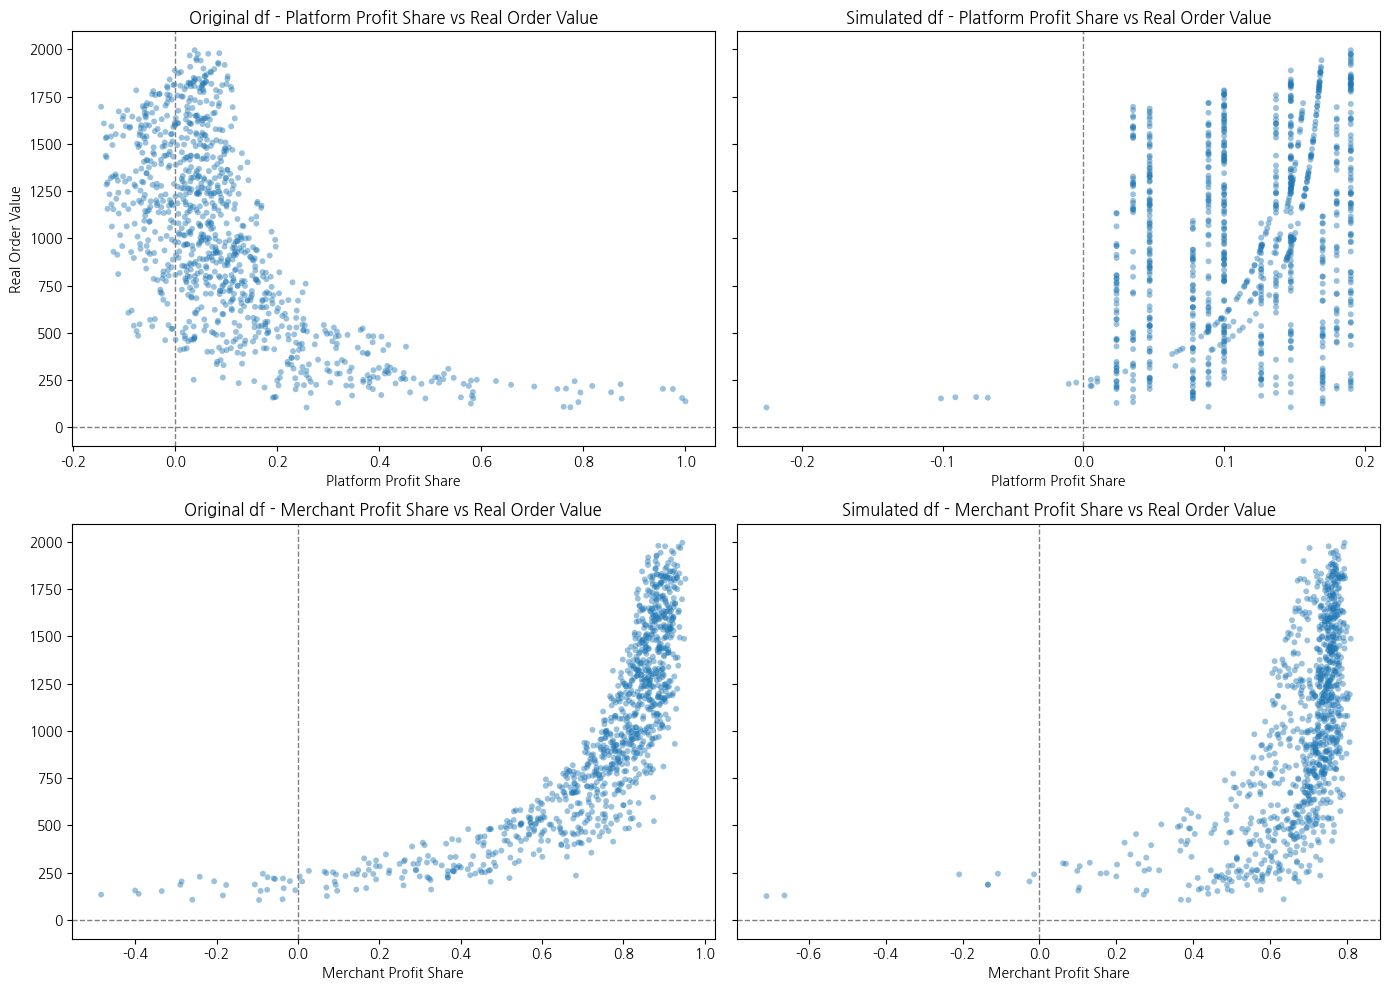

In [47]:
## Scatter plots: Real Order Value vs Platform/Merchant Profit Share

fig, axs = plt.subplots(2, 2, figsize=(14,10), sharex=False, sharey=True)

# 1) df - Platform
sns.scatterplot(data=df, x='Platform Share', y='Real Order Value',
                ax=axs[0,0], s=18, alpha=0.45, edgecolor='none')
axs[0,0].axvline(0, color='gray', linestyle='--', linewidth=1)
axs[0,0].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[0,0].set_title('Original df - Platform Profit Share vs Real Order Value')
axs[0,0].set_xlabel('Platform Profit Share')
axs[0,0].set_ylabel('Real Order Value')

# 2) df - Merchant
sns.scatterplot(data=df, x='Merchant Share', y='Real Order Value',
                ax=axs[1,0], s=18, alpha=0.45, edgecolor='none')
axs[1,0].axvline(0, color='gray', linestyle='--', linewidth=1)
axs[1,0].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[1,0].set_title('Original df - Merchant Profit Share vs Real Order Value')
axs[1,0].set_xlabel('Merchant Profit Share')
axs[1,0].set_ylabel('')

# 3) df_sim - Platform
sns.scatterplot(data=df_sim, x='Platform Share', y='Real Order Value',
                ax=axs[0,1], s=18, alpha=0.45, edgecolor='none')
axs[0,1].axvline(0, color='gray', linestyle='--', linewidth=1)
axs[0,1].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[0,1].set_title('Simulated df - Platform Profit Share vs Real Order Value')
axs[0,1].set_xlabel('Platform Profit Share')
axs[0,1].set_ylabel('Real Order Value')

# 4) df_sim - Merchant
sns.scatterplot(data=df_sim, x='Merchant Share', y='Real Order Value',
                ax=axs[1,1], s=18, alpha=0.45, edgecolor='none')
axs[1,1].axvline(0, color='gray', linestyle='--', linewidth=1)
axs[1,1].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[1,1].set_title('Simulated df - Merchant Profit Share vs Real Order Value')
axs[1,1].set_xlabel('Merchant Profit Share')
axs[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

* When Real Order Value increases, the platform profit appears to decrease,
and when it is low, the platform profit appears even lower. This result seems counterintuitive.
* Instead of showing a negative relationship, Real Order Value and platform profit share would generally be expected to have a positive correlation.

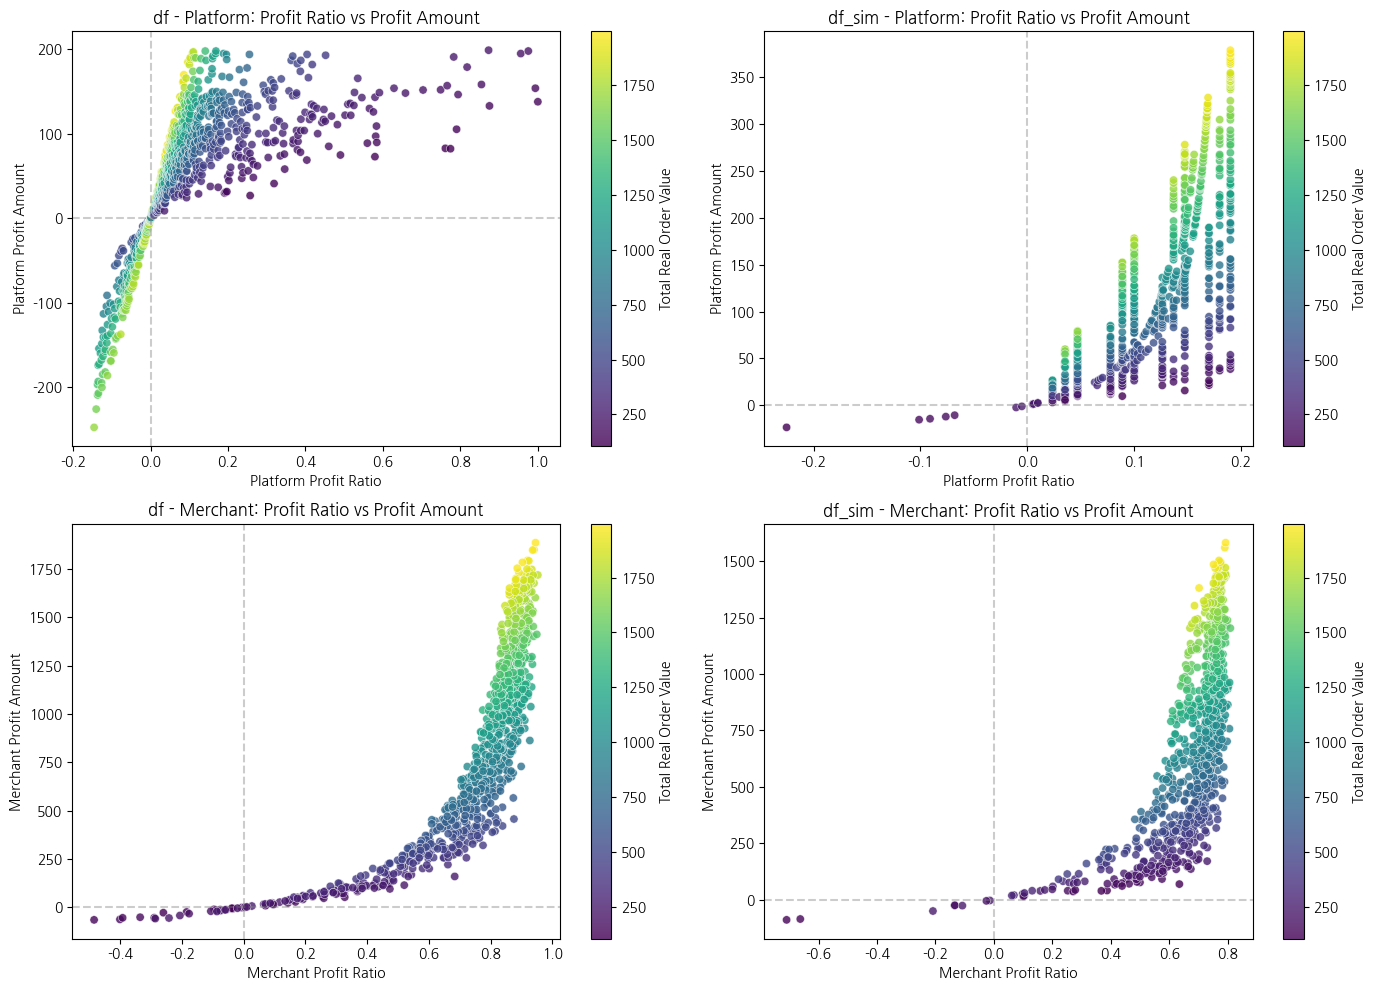

In [48]:
# df base data processing
d_old = df.copy()
g_old = (d_old.assign(px=lambda x: x['Platform Share'],
                      mx=lambda x: x['Merchant Share'],
                      pp=lambda x: x['Platform Profit'],
                      mp=lambda x: x['Merchant Profit'])
         .groupby(['px','pp','mx','mp'], as_index=False)
         .agg(order_value_sum=('Real Order Value', 'sum'))
)

# df_sim base data processing
d_new = df_sim.copy()
g_new = (d_new.assign(px=lambda x: x['Platform Share'],
                      mx=lambda x: x['Merchant Share'],
                      pp=lambda x: x['Platform Profit'],
                      mp=lambda x: x['Merchant Profit'])
         .groupby(['px','pp','mx','mp'], as_index=False)
         .agg(order_value_sum=('Real Order Value', 'sum'))
)

# 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(14,10), sharex=False, sharey=False)

# (0,0) df - Platform
sc1 = axs[0,0].scatter(g_old['px'], g_old['pp'], c=g_old['order_value_sum'],
                       cmap='viridis', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[0,0].set_title('df - Platform: Profit Ratio vs Profit Amount')
axs[0,0].set_xlabel('Platform Profit Ratio')
axs[0,0].set_ylabel('Platform Profit Amount')
fig.colorbar(sc1, ax=axs[0,0], label='Total Real Order Value')

# (1,0) df - Merchant
sc2 = axs[1,0].scatter(g_old['mx'], g_old['mp'], c=g_old['order_value_sum'],
                       cmap='viridis', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[1,0].set_title('df - Merchant: Profit Ratio vs Profit Amount')
axs[1,0].set_xlabel('Merchant Profit Ratio')
axs[1,0].set_ylabel('Merchant Profit Amount')
fig.colorbar(sc2, ax=axs[1,0], label='Total Real Order Value')

# (0,1) df_sim - Platform
sc3 = axs[0,1].scatter(g_new['px'], g_new['pp'], c=g_new['order_value_sum'],
                       cmap='viridis', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[0,1].set_title('df_sim - Platform: Profit Ratio vs Profit Amount')
axs[0,1].set_xlabel('Platform Profit Ratio')
axs[0,1].set_ylabel('Platform Profit Amount')
fig.colorbar(sc3, ax=axs[0,1], label='Total Real Order Value')

# (1,1) df_sim - Merchant
sc4 = axs[1,1].scatter(g_new['mx'], g_new['mp'], c=g_new['order_value_sum'],
                       cmap='viridis', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[1,1].set_title('df_sim - Merchant: Profit Ratio vs Profit Amount')
axs[1,1].set_xlabel('Merchant Profit Ratio')
axs[1,1].set_ylabel('Merchant Profit Amount')
fig.colorbar(sc4, ax=axs[1,1], label='Total Real Order Value')

# add reference lines
for ax in axs.flatten():
    ax.axhline(0, ls='--', c='gray', alpha=0.4)
    ax.axvline(0, ls='--', c='gray', alpha=0.4)

plt.tight_layout()
plt.show()

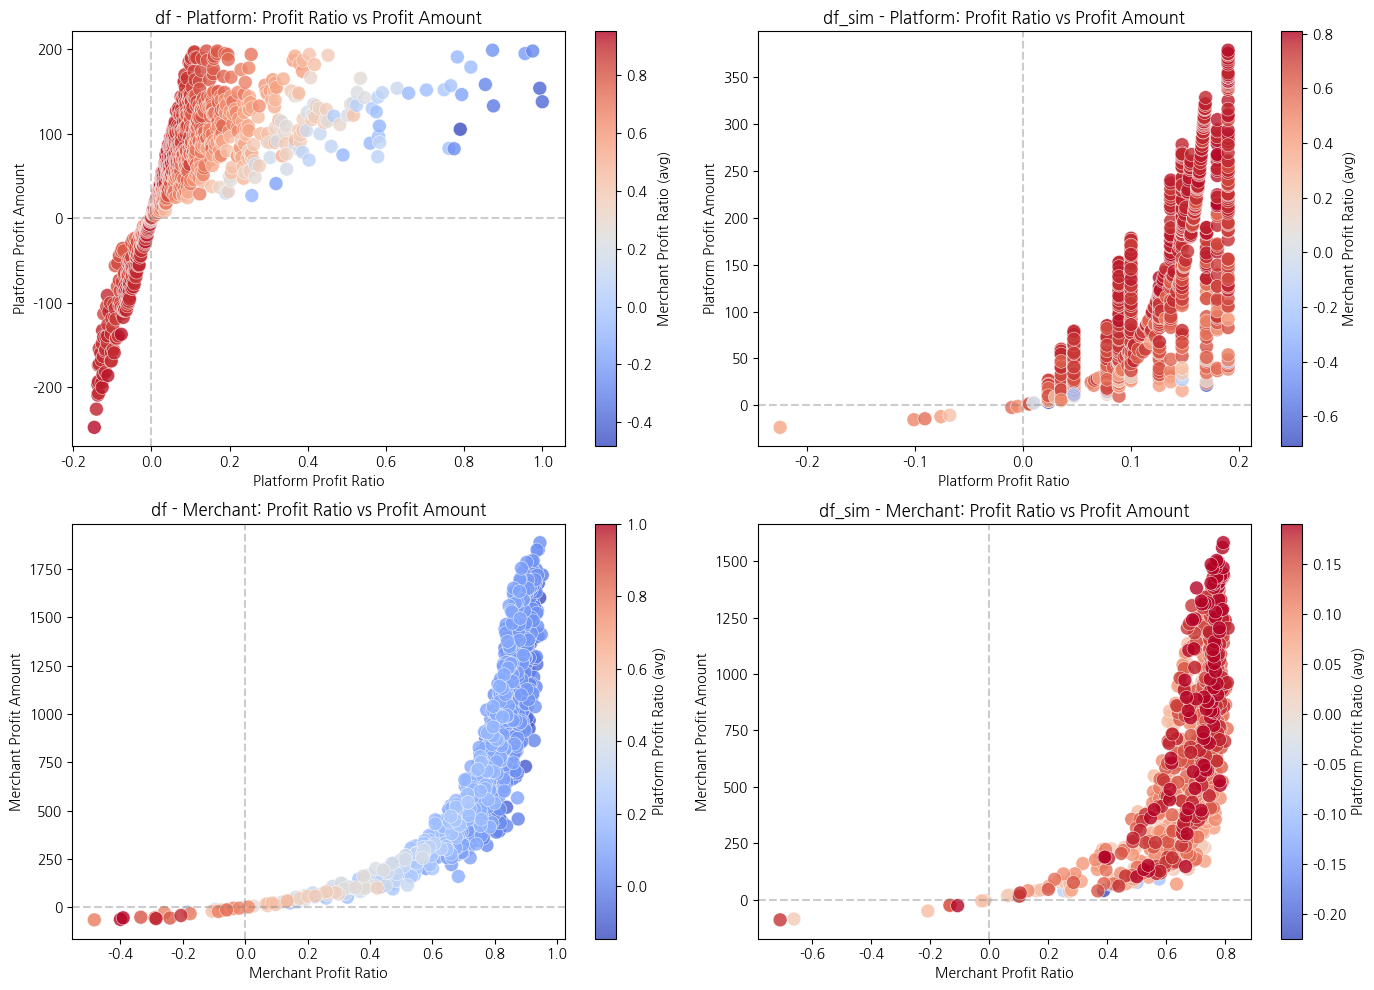

In [49]:
## Relationship between Platform/Merchant Profit Ratio and Profit Amount
# df base data processing
d_old = df.copy()
g_old = (d_old.assign(px=lambda x: x['Platform Share'],
                      mx=lambda x: x['Merchant Share'],
                      pp=lambda x: x['Platform Profit'],
                      mp=lambda x: x['Merchant Profit'])
         .groupby(['px','pp','mx','mp'], as_index=False)
         .size()
         .rename(columns={'size':'count'}))
sizes_old = (np.sqrt(g_old['count'] / g_old['count'].max()) * 100).clip(20, None)

# df_sim base data processing
d_new = df_sim.copy()
g_new = (d_new.assign(px=lambda x: x['Platform Share'],
                      mx=lambda x: x['Merchant Share'],
                      pp=lambda x: x['Platform Profit'],
                      mp=lambda x: x['Merchant Profit'])
         .groupby(['px','pp','mx','mp'], as_index=False)
         .size()
         .rename(columns={'size':'count'}))
sizes_new = (np.sqrt(g_new['count'] / g_new['count'].max()) * 100).clip(20, None)

# 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(14,10), sharex=False, sharey=False)

# (0,0) df - Platform
sc1 = axs[0,0].scatter(g_old['px'], g_old['pp'], s=sizes_old, c=g_old['mx'],
                       cmap='coolwarm', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[0,0].set_title('df - Platform: Profit Ratio vs Profit Amount')
axs[0,0].set_xlabel('Platform Profit Ratio')
axs[0,0].set_ylabel('Platform Profit Amount')
fig.colorbar(sc1, ax=axs[0,0], label='Merchant Profit Ratio (avg)')

# (1,0) df - Merchant
sc2 = axs[1,0].scatter(g_old['mx'], g_old['mp'], s=sizes_old, c=g_old['px'],
                       cmap='coolwarm', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[1,0].set_title('df - Merchant: Profit Ratio vs Profit Amount')
axs[1,0].set_xlabel('Merchant Profit Ratio')
axs[1,0].set_ylabel('Merchant Profit Amount')
fig.colorbar(sc2, ax=axs[1,0], label='Platform Profit Ratio (avg)')

# (0,1) df_sim - Platform
sc3 = axs[0,1].scatter(g_new['px'], g_new['pp'], s=sizes_new, c=g_new['mx'],
                       cmap='coolwarm', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[0,1].set_title('df_sim - Platform: Profit Ratio vs Profit Amount')
axs[0,1].set_xlabel('Platform Profit Ratio')
axs[0,1].set_ylabel('Platform Profit Amount')
fig.colorbar(sc3, ax=axs[0,1], label='Merchant Profit Ratio (avg)')

# (1,1) df_sim - Merchant
sc4 = axs[1,1].scatter(g_new['mx'], g_new['mp'], s=sizes_new, c=g_new['px'],
                       cmap='coolwarm', alpha=0.8, edgecolors='white', linewidths=0.4)
axs[1,1].set_title('df_sim - Merchant: Profit Ratio vs Profit Amount')
axs[1,1].set_xlabel('Merchant Profit Ratio')
axs[1,1].set_ylabel('Merchant Profit Amount')
fig.colorbar(sc4, ax=axs[1,1], label='Platform Profit Ratio (avg)')

# add reference lines
for ax in axs.flatten():
    ax.axhline(0, ls='--', c='gray', alpha=0.4)
    ax.axvline(0, ls='--', c='gray', alpha=0.4)

plt.tight_layout()
plt.show()

**1. Left) As the platform profit ratio increases, the merchant profit ratio decreases.**
* When it exceeds around 0.6, the merchant profit ratio is almost always negative.
* However, in the third quadrant there are some cases where both the profit ratio and profit amount are low, indicating that profit improvement is needed (the commission rate may need adjustment).

**2. Right) When the merchant profit ratio exceeds 0.8, the platform profit ratio often becomes negative.**
* There are regions where both the merchant and the platform achieve high profit amounts, but there are also many transactions where the platform loses both in amount and ratio → structural adjustment is required.


* **Differential Commission Rates by Segment ⭐️**

1. Divide the segments into the top **35%**, the next **65%**, and the remaining portion
2. Apply commission rates of **17%, 18%, and 19%** to each segment — higher sales receive a lower commission rate

## 03. Finding the Optimal Cost-Sharing Scenario for Delivery Fees / Promotion Costs

In [50]:
def calculate_shares_by_scenario(df_sim):

    # 9가지 시나리오 정의 (Platform / Merchant 부담 비율)
    scenarios = [
        {"name": "scenario_1", "discount": (0.7,0.3), "delivery": (0.5,0.5)},
        {"name": "scenario_2", "discount": (0.3,0.7), "delivery": (0.5,0.5)},
        {"name": "scenario_3", "discount": (0.5,0.5), "delivery": (0.7,0.3)},
        {"name": "scenario_4", "discount": (0.5,0.5), "delivery": (0.3,0.7)},
        {"name": "scenario_5", "discount": (0.5,0.5), "delivery": (0.5,0.5)},
        {"name": "scenario_6", "discount": (0.3,0.7), "delivery": (0.3,0.7)},
        {"name": "scenario_7", "discount": (0.7,0.3), "delivery": (0.7,0.3)},
        {"name": "scenario_8", "discount": (0.3,0.7), "delivery": (0.7,0.3)},
        {"name": "scenario_9", "discount": (0.7,0.3), "delivery": (0.3,0.7)}
    ]

    results = []

    for s in scenarios:
        temp = df_sim.copy()

        # iv. Platform Profit
        temp['Platform Profit'] = temp['Commission Fee'] - temp['Discount Cost'] * s['discount'][0] - (temp['Delivery Fee'] * s['delivery'][0])

        # v. Merchant Profit
        temp['Merchant Profit'] = temp['Real Order Value'] - temp['Commission Fee'] - (temp['Discount Cost'] * s['discount'][1]) - (temp['Delivery Fee'] * s['delivery'][1]) - temp['Payment Processing Fee'] - temp['Refunds/Chargebacks']

        # vi, vii. Platform / Merchant Share
        temp['Platform Share'] = temp['Platform Profit'] / temp['Real Order Value']
        temp['Merchant Share'] = temp['Merchant Profit'] / temp['Real Order Value']
        temp['Platform_share_change'] = temp['Platform Share'] - df_sim['Platform Share']
        temp['Merchant_share_change'] = temp['Merchant Share'] - df_sim['Merchant Share']

        results.append({
            "scenario": s["name"],
            "Platform Share": temp['Platform Share'].mean(),
            "Platform Share Change (%p)": (temp['Platform_share_change'].mean())*100,
            "Merchant Share": temp['Merchant Share'].mean(),
            "Merchant Share Change (%p)": (temp['Merchant_share_change'].mean())*100
        })

    return pd.DataFrame(results)

# 1) df_sim 평균 Platform / Merchant Share 계산
platform_sim_avg = df_sim['Platform Share'].mean()
merchant_sim_avg = df_sim['Merchant Share'].mean()

# 2) 9개 시나리오 계산
df_scenarios = calculate_shares_by_scenario(df_sim)

print("Original Share:")
print(f"Platform Share: {round(platform_sim_avg,3) * 100} %")
print(f"Merchant Share: {round(merchant_sim_avg,3) * 100} %")

print("Shares by scenarios:")
df_scenarios.sort_values(by='Platform Share Change (%p)', ascending=False)

Original Share:
Platform Share: 11.4 %
Merchant Share: 67.4 %
Shares by scenarios:


,scenario,Platform Share,Platform Share Change (%p),Merchant Share,Merchant Share Change (%p)
5,scenario_6,0.160162,4.567149,0.628149,-4.567149
1,scenario_2,0.151687,3.719660,0.636624,-3.719660
3,scenario_4,0.143481,2.899040,0.644830,-2.899040
7,scenario_8,0.143212,2.872171,0.645099,-2.872171
4,scenario_5,0.135006,2.051551,0.653305,-2.051551
8,scenario_9,0.126800,1.230930,0.661511,-1.230930
2,scenario_3,0.126531,1.204062,0.661780,-1.204062
0,scenario_1,0.118325,0.383441,0.669986,-0.383441
6,scenario_7,0.109850,-0.464048,0.678461,0.464048


* All scenarios result in a decrease in the merchant profit margin.
* Scenario 1 causes the least loss to merchants while still providing benefits to the platform.


## 04. Visualization of the Optimal Cost-Sharing Scenario

In [51]:
df_final = df_sim.copy()

df_final['Discount Cost Platform'] = df_final['Discount Cost']*0.7  # Platform 70% 부담
df_final['Discount Cost Merchant'] = df_final['Discount Cost']*0.3  # Merchant 30% 부담
df_final['Delivery Fee Platform'] = df_sim['Delivery Fee']*0.5      # Platform 50% 부담
df_final['Delivery Fee Merchant'] = df_sim['Delivery Fee']*0.5    # Merchant 50% 부담
df_final['Commission Fee'] = (df_final['Order Value']-df_final['Discount Cost Merchant']) * df_final['fee_rate']

# 플랫폼/업주 수익 계산
df_final['Platform Profit'] = df_final['Commission Fee'] - df_final['Discount Cost Platform'] - df_final['Delivery Fee Platform']
df_final['Merchant Profit'] = df_final['Real Order Value'] - df_final['Commission Fee'] - df_final['Payment Processing Fee'] - df_final['Delivery Fee Merchant'] - df_final['Discount Cost Merchant'] - df_final['Refunds/Chargebacks']

# 수익률 계산
df_final['Platform Share'] = df_final['Platform Profit'] / df_final['Real Order Value']
df_final['Merchant Share'] = df_final['Merchant Profit'] / df_final['Real Order Value']


In [53]:
# 수수료율만 적용했을 때 대비

df_result = pd.DataFrame({
    'Existing_Platform_Avg_Profit_Ratio' : [df_sim['Platform Share'].mean()],
    'Simulated_Platform_Avg_Profit_Ratio' : [df_final['Platform Share'].mean()],
    'Platform_Avg_Profit_Ratio_Change' : [df_final['Platform Share'].mean()-df_sim['Platform Share'].mean()],
    'Existing_Merchant_Avg_Profit_Ratio' : [df_sim['Merchant Share'].mean()],
    'Simulated_Merchant_Avg_Profit_Ratio' : [df_final['Merchant Share'].mean()],
    'Merchant_Avg_Profit_Ratio_Change' : [df_final['Merchant Share'].mean()-df_sim['Merchant Share'].mean()],
})

df_result

,Existing_Platform_Avg_Profit_Ratio,Simulated_Platform_Avg_Profit_Ratio,Platform_Avg_Profit_Ratio_Change,Existing_Merchant_Avg_Profit_Ratio,Simulated_Merchant_Avg_Profit_Ratio,Merchant_Avg_Profit_Ratio_Change
0,0.11449,0.113808,-0.000682,0.673821,0.674983,0.001163


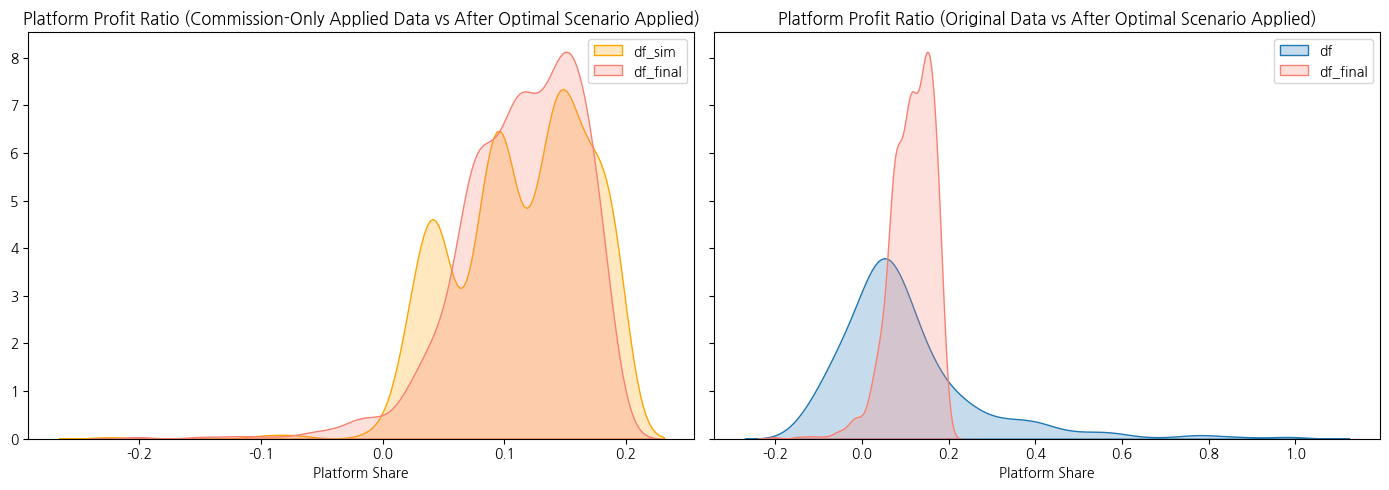

In [54]:
# Platform profit ratio distribution comparison
fig, axs = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Left: df (before commission applied) vs df_final (after optimal scenario applied)
sns.kdeplot(df['Platform Share'], ax=axs[1], label='df', fill=True)
sns.kdeplot(df_final['Platform Share'], ax=axs[1], label='df_final', color='salmon', fill=True)
axs[1].set_title('Platform Profit Ratio (Original Data vs After Optimal Scenario Applied)')
axs[1].set_xlabel('Platform Share')
axs[1].set_ylabel('Density')
axs[1].legend()

# Right: df_sim (after optimal commission rate applied) vs df_final (optimal scenario)
sns.kdeplot(df_sim['Platform Share'], ax=axs[0], label='df_sim', color='orange', fill=True)
sns.kdeplot(df_final['Platform Share'], ax=axs[0], label='df_final', color='salmon', fill=True)
axs[0].set_title('Platform Profit Ratio (Commission-Only Applied Data vs After Optimal Scenario Applied)')
axs[0].set_xlabel('Platform Share')
axs[0].set_ylabel('')
axs[0].legend()

plt.tight_layout()
plt.show()

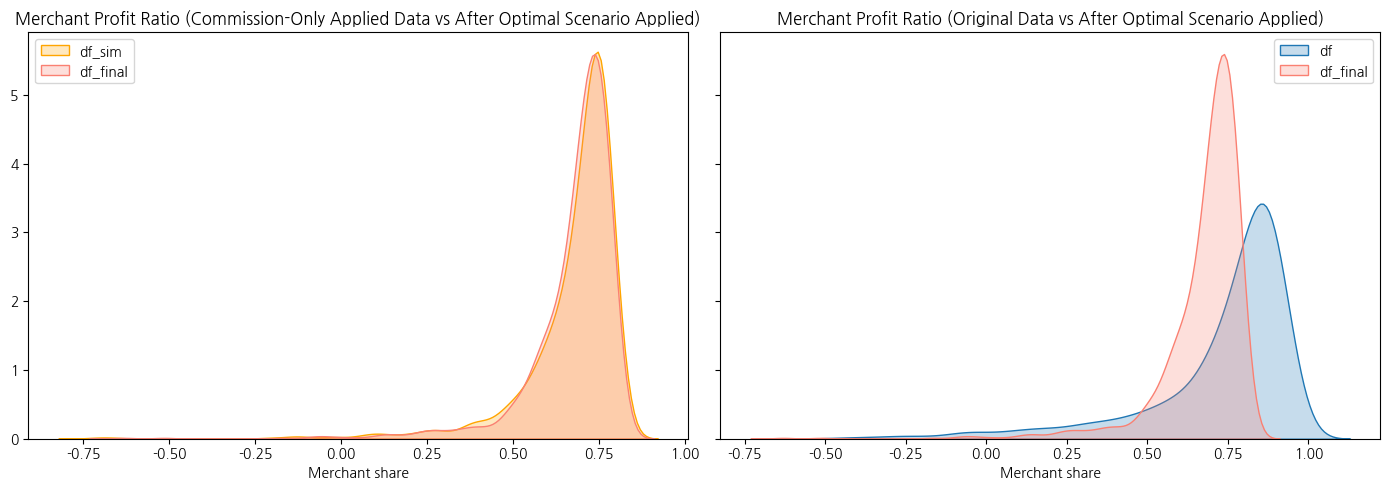

In [55]:
# Merchant profit ratio distribution comparison
fig, axs = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Left: df (before commission applied) vs df_final (optimal scenario)
sns.kdeplot(df['Merchant Share'], ax=axs[1], label='df', fill=True)
sns.kdeplot(df_final['Merchant Share'], ax=axs[1], label='df_final',color='salmon', fill=True)
axs[1].set_title('Merchant Profit Ratio (Original Data vs After Optimal Scenario Applied)')
axs[1].set_xlabel('Merchant share')
axs[1].set_ylabel('Density')
axs[1].legend()

# Right: df_sim (after optimal commission rate applied) vs df_final (optimal scenario)
sns.kdeplot(df_sim['Merchant Share'], ax=axs[0], label='df_sim', color='orange', fill=True)
sns.kdeplot(df_final['Merchant Share'], ax=axs[0], label='df_final', color='salmon', fill=True)
axs[0].set_title('Merchant Profit Ratio (Commission-Only Applied Data vs After Optimal Scenario Applied)')
axs[0].set_xlabel('Merchant share')
axs[0].set_ylabel('')
axs[0].legend()

plt.tight_layout()
plt.show()

# **4. Management Strategy**

### **1) Finalization of Cost Sharing and Commission Fee**


In [56]:
def add_fee_rate(df):
    # 기존 열 삭제
    if 'fee_rate' in df.columns:
        df = df.drop(columns=['fee_rate'])

    # 가게별 총 매출 집계
    sales = (df.groupby('Restaurant ID', as_index=False)['Real Order Value']
               .sum()
               .rename(columns={'Real Order Value':'total_sales'}))

    # 매출 백분위 구하기
    sales['pct'] = sales['total_sales'].rank(ascending=False, pct=True) * 100

    # 구간별 fee_rate 할당
    sales['fee_rate'] = pd.cut(
        sales['pct'],
        bins=[-1, 35, 65, 100],
        labels=[0.13, 0.12, 0.11],
        right=True
    ).astype(float)

    # 원본과 병합
    df_with_fee = df.merge(sales[['Restaurant ID', 'fee_rate']], on='Restaurant ID', how='left')

    return df_with_fee


df = add_fee_rate(df)

In [57]:
# F: Final
df['F Discount Cost Platform'] = df['Discount Cost']*0.3  # Platform 30% Covered
df['F Discount Cost Merchant'] = df['Discount Cost']*0.7  # Merchant 70% Covered
df['F Delivery Fee Platform'] = df['Delivery Fee']*0.3      # Platform 30% Covered
df['F Delivery Fee Merchant'] = df['Delivery Fee']*0.7    # Merchant 70% Covered
df['F Commission Fee'] = (df['Order Value']-df['F Discount Cost Merchant']) * df['fee_rate']

# 플랫폼/업주 수익 계산
df['F Platform Profit'] = df['F Commission Fee'] - df['F Discount Cost Platform'] - df['F Delivery Fee Platform']
df['F Merchant Profit'] = df['Real Order Value'] - df['F Commission Fee'] - df['Payment Processing Fee'] - df['F Delivery Fee Merchant']

# 수익률 계산
df['F Platform Share'] = df['F Platform Profit'] / df['Real Order Value']
df['F Merchant Share'] = df['F Merchant Profit'] / df['Real Order Value']

print(df['F Platform Profit'].mean())
print(df['F Platform Profit'].sum() / df['Real Order Value'].sum())
print(df['F Merchant Profit'].sum() / df['Real Order Value'].sum())

96.5274515946502
0.09609859185512391
0.8231276441477348


In [58]:
df_final = df.copy()

In [59]:
result = (
    df_final.groupby('Discounts and Offers')
      .agg(
          F_Platform_Profit_mean=('F Platform Profit', 'mean'),
          Count=('F Platform Profit', 'count')
      )
      .reset_index()
)

# 그룹별 가중평균 계산
weighted_share = df_final.groupby('Discounts and Offers').apply(
    lambda x: x['F Platform Profit'].sum() / x['Real Order Value'].sum()
).reset_index(name='F_Platform_Share_Weighted')

# result와 병합
result = result.merge(weighted_share, on='Discounts and Offers')

# 비중 컬럼 추가
result['Ratio (%)'] = (result['Count'] / result['Count'].sum() * 100).round(2)

# 정렬
result = result.sort_values(by='Ratio (%)', ascending=False).reset_index(drop=True)
result

# weight is big in this order 10% -> 50 off -> 15% -> 0 -> 5%


/tmp/ipykernel_678/1429434325.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_share = df_final.groupby('Discounts and Offers').apply(


,Discounts and Offers,F_Platform_Profit_mean,Count,F_Platform_Share_Weighted,Ratio (%)
0,10%,83.185771,229,0.086415,23.56
1,50 off Promo,113.009171,193,0.104264,19.86
2,15% New User,60.917086,189,0.068287,19.44
3,0,123.880055,182,0.116579,18.72
4,5% on App,105.613810,179,0.102350,18.42


### 2) **15% Coupon Adjustment**:
#### Customers who used a 15% coupon on their second order are restricted from using a 15% coupon on that order.

In [60]:
# 1. 고객별 주문 건수가 2 이상인 고객
repeat_customers = df_final.groupby('Customer ID')['Order ID'].count()
repeat_customers = repeat_customers[repeat_customers >= 2].index

# 2. 두 번 이상 주문한 고객 주문 데이터 필터
df_repeat = df_final[df_final['Customer ID'].isin(repeat_customers)].copy()

# 3. 주문일시 기준 정렬
df_repeat['Order Date and Time'] = pd.to_datetime(df_repeat['Order Date and Time'])
df_repeat = df_repeat.sort_values(['Customer ID', 'Order Date and Time'])

# 4. 각 고객 주문 순서 번호 부여
df_repeat['Order_Number'] = df_repeat.groupby('Customer ID').cumcount() + 1

# 5. 첫 번째와 두 번째 주문만 선택
df_first_second = df_repeat[df_repeat['Order_Number'].isin([1,2])]

# 6. 각 고객의 두 주문 쿠폰 리스트 만들기
coupon_list = df_first_second.groupby('Customer ID')['Discounts and Offers'].apply(list)

# 7. 두 번 모두 15% 쿠폰 사용한 고객 필터
customers_two_15 = coupon_list[coupon_list.apply(lambda x: x == ['15%', '15%'] or x == ['15% New User', '15% New User'])]

# 8. 고객 수 확인
num_customers_two_15 = customers_two_15.shape[0]

print(f"Number of Customers Who Used a 15% Coupon Twice in a Row: {num_customers_two_15}")

customers_two_15

Number of Customers Who Used a 15% Coupon Twice in a Row: 3


,Discounts and Offers
Customer ID,
C4170,"[15% New User, 15% New User]"
C4627,"[15% New User, 15% New User]"
C5380,"[15% New User, 15% New User]"


* The second coupon is assumed not to exist -> set to 0

In [61]:
# 1️⃣ 고객별 주문 순서 만들기

df_15to0= df_final.copy()
df_15to0['Order Date and Time'] = pd.to_datetime(df_15to0['Order Date and Time'])
df_15to0 = df_15to0.sort_values(['Customer ID', 'Order Date and Time'])
df_15to0['Order_Number'] = df_15to0.groupby('Customer ID').cumcount() + 1

# 2️⃣ 두 번 연속 15% 쿠폰 사용 고객 찾기
df_first_second = df_15to0[df_15to0['Order_Number'].isin([1,2])]
coupon_list = df_first_second.groupby('Customer ID')['Discounts and Offers'].apply(list)
customers_two_15 = coupon_list[coupon_list.apply(lambda x: x == ['15% New User','15% New User'])].index

# 3️⃣ 두 번째 주문만 복사해서 쿠폰 0으로 변경
df_modified = df_15to0.copy()

mask = (df_modified['Customer ID'].isin(customers_two_15)) & (df_modified['Order_Number'] == 2)
df_modified.loc[mask, 'Discounts and Offers'] = 0
df_modified['Discount Cost'] = df_modified.apply(calculate_discount_amount, axis=1)
df_modified['Real Order Value'] = df_modified['Order Value'] - df_modified['Discount Cost']
df_modified = add_fee_rate(df_modified)  # 수수료율도 재 설정

df_modified['F Discount Cost Platform'] = 0.3 * df_modified['Discount Cost']
df_modified['F Discount Cost Merchant'] = 0.7 * df_modified['Discount Cost']


df_modified['F Commission Fee'] = (df_modified['Order Value'] - df_modified['F Discount Cost Merchant']) * df_modified['fee_rate']

# F Platform Profit과 Share 재계산
df_modified['F Platform Profit'] = (df_modified['F Commission Fee'] - df_modified['F Discount Cost Platform'] - df_modified['F Delivery Fee Platform'])
df_modified['F Platform Share'] = df_modified['F Platform Profit'] / df_modified['Real Order Value']

df_modified['F Merchant Profit'] = df_modified['Real Order Value'] - df_modified['F Commission Fee'] - df_modified['Payment Processing Fee'] - df_modified['F Delivery Fee Merchant']
df_modified['F Merchant Share'] = df_modified['F Merchant Profit'] / df_modified['Real Order Value']

# 혹시 숫자 0이 있으면 문자열 "0"으로 통일
df_modified['Discounts and Offers'] = df_modified['Discounts and Offers'].astype(str)
df_modified['Discounts and Offers'] = df_modified['Discounts and Offers'].replace({'0.0': '0', 0: '0'})

# 5️⃣ 전체 평균 수익률 확인
old_profit = df_15to0['F Platform Profit'].mean()
old_share = df_15to0['F Platform Profit'].sum() / df_15to0['Real Order Value'].sum()

print(f"old avg platform Profit: {old_profit:.2f}")
print(f"old avg platform Share: {old_share:.4f}")

avg_profit = df_modified['F Platform Profit'].mean()
avg_share = df_modified['F Platform Profit'].sum() / df_modified['Real Order Value'].sum()

print(f"new avg platform Profit: {avg_profit:.2f}")
print(f"new avg platform Share: {avg_share:.4f}")

old avg platform Profit: 96.53
old avg platform Share: 0.0961
new avg platform Profit: 96.73
new avg platform Share: 0.0963


In [62]:
# Function to check profit, profit ratio, order count, and share by coupon

def compute_grouped_profit_summary(df, profit_col='F Platform Profit', value_col='Real Order Value', group_col='Discounts and Offers'):
    """
    Function to calculate mean, weighted average profit ratio, count, and share by group

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame to analyze
    profit_col : str
        Profit column name
    value_col : str
        Real order value column name used for weighted average calculation
    group_col : str
        Column name used for grouping

    Returns
    -------
    pd.DataFrame
        Summary results by group
    """

    # Simple mean and count by group
    result = (
        df.groupby(group_col)
          .agg(
              Profit_Mean=(profit_col, 'mean'),
              Count=(profit_col, 'count')
          )
          .reset_index()
    )

    # Calculate weighted average profit ratio by group
    weighted_share = (
        df.groupby(group_col)[[profit_col, value_col]]
          .apply(lambda x: x[profit_col].sum() / x[value_col].sum())
          .reset_index(name=f'{profit_col} weighted mean')
    )
    result = result.merge(weighted_share, on=group_col)
    result['Ratio (%)'] = (result['Count'] / result['Count'].sum() * 100).round(2)

    # Sort by share
    result = result.sort_values(by='Ratio (%)', ascending=False).reset_index(drop=True)

    return result

In [63]:
coupon_share_summary_15 = compute_grouped_profit_summary(df_modified)
coupon_share_summary_15

,Discounts and Offers,Profit_Mean,Count,F Platform Profit weighted mean,Ratio (%)
0,10%,83.185771,229,0.086415,23.56
1,50 off Promo,113.009171,193,0.104264,19.86
2,15% New User,60.807569,186,0.068246,19.14
3,0,124.039730,185,0.116613,19.03
4,5% on App,105.613810,179,0.102350,18.42


### **2) 10% Coupon Mix Adjustment Promotion**

* Divide the range from the average of total order value up to the top 10% into 10 segments, and set these as the spending thresholds for selecting VIP customers.
* Among the 10 scenarios, select the one where both the platform and the merchant show profit margin improvements while also having the smallest gap between the best and worst profit outcomes.
* Due to dataset limitations, assume that next month’s orders will be identical to this month’s orders and evaluate the resulting change in profit margins.


#### Coupon Distribution Simulation

* How should the proportions of **0% discount, 50 off Promo, and 5%** be adjusted?
* Option 1: Equal distribution 1:1:1 ✅
* Option 2: Profit-rate-based weighting


In [64]:
def simulate_vip_thresholds(df, n_iter=200, n_thresholds=10):
    np.random.seed(100)
    df = df.copy()
    customer_sales = df.groupby('Customer ID')['Order Value'].sum()
    mean_val = customer_sales.mean()
    p90 = customer_sales.quantile(0.9)

    thresholds = np.linspace(mean_val, p90, n_thresholds)
    results = []

    for vip_threshold in thresholds:
        vip_customers = customer_sales[customer_sales >= vip_threshold].index
        mask_vip = (df['Customer ID'].isin(vip_customers)) & (df['Discounts and Offers'].str.contains('10%'))

        best_profit = -np.inf
        worst_profit = np.inf
        best_df = None
        worst_df = None
        total_target_orders = 0

        for _ in range(n_iter):
            df_iter = df.copy()
            # Conversion target: 10% coupon orders from non-VIP customers
            mask_target = (df_iter['Discounts and Offers'].str.contains('10%')) & (~mask_vip)
            target_idx = df_iter[mask_target].index
            total_target_orders = len(target_idx)

            # Conversion: equal distribution
            choices = np.random.choice(['0', '50 off Promo', '5% on App'], size=len(target_idx), p=[1/3,1/3,1/3])
            df_iter.loc[target_idx, 'Discounts and Offers'] = choices

            # Profit calculation
            df_iter = add_fee_rate(df_iter)
            df_iter['Discount Cost'] = df_iter.apply(calculate_discount_amount, axis=1)
            df_iter['Real Order Value'] = df_iter['Order Value'] - df_iter['Discount Cost']
            df_iter['F Discount Cost Platform'] = df_iter['Discount Cost']*0.3
            df_iter['F Discount Cost Merchant'] = df_iter['Discount Cost']*0.7
            df_iter['F Delivery Fee Platform'] = df_iter['Delivery Fee']*0.3
            df_iter['F Delivery Fee Merchant'] = df_iter['Delivery Fee']*0.7
            df_iter['F Commission Fee'] = (df_iter['Order Value']-df_iter['F Discount Cost Merchant']) * df_iter['fee_rate']
            df_iter['F Platform Profit'] = df_iter['F Commission Fee'] - df_iter['F Discount Cost Platform'] - df_iter['F Delivery Fee Platform']
            df_iter['F Merchant Profit'] = df_iter['Real Order Value'] - df_iter['F Commission Fee'] - df_iter['Payment Processing Fee'] - df_iter['F Delivery Fee Merchant']

            profit_total = df_iter['F Platform Profit'].sum()
            if profit_total > best_profit:
                best_profit = profit_total
                best_df = df_iter.copy()
            if profit_total < worst_profit:
                worst_profit = profit_total
                worst_df = df_iter.copy()

        results.append({
            # VIP information
            'VIP threshold amount': vip_threshold,
            'Number of VIP customers': len(vip_customers),
            'Number of target orders for conversion': total_target_orders,
            'Target conversion ratio [%]': total_target_orders / df[df['Discounts and Offers'].str.contains('10%')].shape[0]*100,

            # best_df (platform highest profit scenario)
            'P avg profit (best)': best_df['F Platform Profit'].mean(),
            'P total profit (best)': best_df['F Platform Profit'].sum(),
            'P profit margin [%] (best)': (best_df['F Platform Profit'].sum() / best_df['Real Order Value'].sum())*100,
            'M avg profit (best)': best_df['F Merchant Profit'].mean(),
            'M total profit (best)': best_df['F Merchant Profit'].sum(),
            'M profit margin [%] (best)': (best_df['F Merchant Profit'].sum() / best_df['Real Order Value'].sum())*100,

            # worst_df (platform lowest profit scenario)
            'P avg profit (worst)': worst_df['F Platform Profit'].mean(),
            'P total profit (worst)': worst_df['F Platform Profit'].sum(),
            'P profit margin [%] (worst)': (worst_df['F Platform Profit'].sum() / worst_df['Real Order Value'].sum())*100,
            'M avg profit (worst)': worst_df['F Merchant Profit'].mean(),
            'M total profit (worst)': worst_df['F Merchant Profit'].sum(),
            'M profit margin [%] (worst)': (worst_df['F Merchant Profit'].sum() / worst_df['Real Order Value'].sum())*100,

            # Best-Worst difference calculation
            'P total profit difference': best_df['F Platform Profit'].sum() - worst_df['F Platform Profit'].sum(),
            'M total profit difference': best_df['F Merchant Profit'].sum() - worst_df['F Merchant Profit'].sum()
            })

    df_results = pd.DataFrame(results)
    min_diff_idx = df_results['P total profit difference'].idxmin()

    # Highlight the row with the minimum P total profit difference
    def highlight_row(row):
        if row.name == min_diff_idx:
            return ['background-color: salmon'] * len(row)
        else:
            return [''] * len(row)

    df_styled = df_results.style.apply(highlight_row, axis=1)

    return df_results, df_styled

# Run
vip_sim_results, vip_sim_highlight = simulate_vip_thresholds(df_modified)
vip_sim_highlight

,VIP threshold amount,Number of VIP customers,Number of target orders for conversion,Target conversion ratio [%],P avg profit (best),P total profit (best),P profit margin [%] (best),M avg profit (best),M total profit (best),M profit margin [%] (best),P avg profit (worst),P total profit (worst),P profit margin [%] (worst),M avg profit (worst),M total profit (worst),M profit margin [%] (worst),P total profit difference,M total profit difference
0,1141.256522,438,118,51.528384,98.768787,96003.260900,9.776383,832.121486,808822.084100,82.365475,98.237740,95487.083350,9.737124,830.857810,807593.791650,82.352929,516.177550,1228.292450
1,1220.928019,404,130,56.768559,99.200964,96423.336650,9.808245,833.151007,809822.778350,82.375700,98.684414,95921.250500,9.770105,831.927067,808633.109500,82.363714,502.086150,1189.668850
2,1300.599517,369,134,58.515284,99.229824,96451.388950,9.810474,833.205737,809875.976050,82.375874,98.753549,95988.449200,9.775254,832.085767,808787.365800,82.365135,462.939750,1088.610250
3,1380.271014,316,146,63.755459,99.756693,96963.505350,9.849137,834.471383,811106.184650,82.388689,99.167391,96390.704100,9.805840,833.061868,809736.135900,82.374574,572.801250,1370.048750
4,1459.942512,282,152,66.375546,99.957972,97159.148700,9.864030,834.934816,811556.641300,82.392850,99.360727,96578.626700,9.820194,833.506228,810168.053300,82.378556,580.522000,1388.588000
5,1539.614010,247,157,68.558952,100.196696,97391.188450,9.881607,835.493412,812099.596550,82.398103,99.619057,96829.723800,9.839151,834.126869,810771.316200,82.384843,561.464650,1328.280350
6,1619.285507,201,171,74.672489,100.836612,98013.187200,9.928577,836.996356,813560.457800,82.412354,100.166996,97362.319900,9.879458,835.418992,812027.260100,82.397272,650.867300,1533.197700
7,1698.957005,166,179,78.165939,101.281683,98445.795400,9.961163,838.040601,814575.464600,82.422199,100.530678,97715.818700,9.906236,836.265099,812849.676300,82.405088,729.976700,1725.788300
8,1778.628502,137,190,82.969432,101.778093,98928.306550,9.997403,839.207709,815709.893450,82.433241,101.071810,98241.799200,9.945843,837.543298,814092.085800,82.417383,686.507350,1617.807650
9,1858.300000,92,199,86.899563,102.348286,99482.534000,10.038964,840.542244,817007.061000,82.445673,101.560190,98716.505150,9.981560,838.688277,815205.004850,82.428141,766.028850,1802.056150


Scenario 3 is the most stable scenario, but because the improvement in profit margin is minimal, Scenario 6 was selected.


In [65]:
# What percentage of customers are considered VIP?

# customer_sales is the total order value per customer
customer_sales = df_modified.groupby('Customer ID')['Order Value'].sum()

# Recalculate thresholds
mean_val = customer_sales.mean()
p90 = customer_sales.quantile(0.9)
n_thresholds = 10
thresholds = np.linspace(mean_val, p90, n_thresholds)

# Scenario 6 (index 5)
idx = 5
vip_threshold = thresholds[idx]
vip_customers = customer_sales[customer_sales >= vip_threshold].index
vip_ratio = len(vip_customers) / len(customer_sales) * 100

print(f"Scenario 6 VIP threshold amount: {vip_threshold:.2f}")
print(f"Top {vip_ratio:.2f}% of customers are VIP")

Scenario 6 VIP threshold amount: 1539.61
Top 26.85% of customers are VIP


#### Extract Best/Worst Cases Based on Scenario 6


In [66]:
# 1. 고객별 총 주문금액 계산
customer_sales = df_modified.groupby('Customer ID')['Order Value'].sum()

# 2. thresholds 계산 (n_thresholds=10 기준)
mean_val = customer_sales.mean()
p90 = customer_sales.quantile(0.9)
n_thresholds = 10
thresholds = np.linspace(mean_val, p90, n_thresholds)

# 3. 6번째 시나리오 기준 VIP 금액
mask_vip = (df_modified['Customer ID'].isin(vip_customers)) & (df_modified['Discounts and Offers'].str.contains('10%'))

# 4. best/worst 시나리오 초기화
best_profit = -np.inf
worst_profit = np.inf
best_df = None
worst_df = None

n_iter = 200  # 시뮬레이션 반복 횟수
np.random.seed(100) # 시드 고정

for _ in range(n_iter):
    df_iter = df_modified.copy()

    # VIP 아닌 10% 쿠폰 주문 전환 대상
    mask_target = (df_iter['Discounts and Offers'].str.contains('10%')) & (~mask_vip)
    target_idx = df_iter[mask_target].index

    # 균등 랜덤 전환
    choices = np.random.choice(['0', '50 off Promo', '5% on App'], size=len(target_idx), p=[1/3,1/3,1/3])
    df_iter.loc[target_idx, 'Discounts and Offers'] = choices

    # 수익 계산
    df_iter = add_fee_rate(df_iter)
    df_iter['Discount Cost'] = df_iter.apply(calculate_discount_amount, axis=1)
    df_iter['Real Order Value'] = df_iter['Order Value'] - df_iter['Discount Cost']
    df_iter['F Discount Cost Platform'] = df_iter['Discount Cost']*0.3
    df_iter['F Discount Cost Merchant'] = df_iter['Discount Cost']*0.7
    df_iter['F Delivery Fee Platform'] = df_iter['Delivery Fee']*0.3
    df_iter['F Delivery Fee Merchant'] = df_iter['Delivery Fee']*0.7
    df_iter['F Commission Fee'] = (df_iter['Order Value']-df_iter['F Discount Cost Merchant']) * df_iter['fee_rate']
    df_iter['F Platform Profit'] = df_iter['F Commission Fee'] - df_iter['F Discount Cost Platform'] - df_iter['F Delivery Fee Platform']
    df_iter['F Merchant Profit'] = df_iter['Real Order Value'] - df_iter['F Commission Fee'] - df_iter['Payment Processing Fee'] - df_iter['F Delivery Fee Merchant']
    df_iter['F Platform Share'] = df_iter['F Platform Profit'] / df_iter['Real Order Value']
    df_iter['F Merchant Share'] = df_iter['F Merchant Profit'] / df_iter['Real Order Value']

    profit_total = df_iter['F Platform Profit'].sum()

    if profit_total > best_profit:
        best_profit = profit_total
        df_best = df_iter.copy()

    if profit_total < worst_profit:
        worst_profit = profit_total
        df_worst = df_iter.copy()

In [67]:
compute_grouped_profit_summary(df_best)

,Discounts and Offers,Profit_Mean,Count,F Platform Profit weighted mean,Ratio (%)
0,0,117.106640,250,0.115604,25.72
1,50 off Promo,104.196776,245,0.102546,25.21
2,5% on App,97.899371,219,0.101398,22.53
3,15% New User,60.807569,186,0.068246,19.14
4,10%,136.361992,72,0.092474,7.41


In [68]:
compute_grouped_profit_summary(df_worst)

,Discounts and Offers,Profit_Mean,Count,F Platform Profit weighted mean,Ratio (%)
0,50 off Promo,101.152040,250,0.101449,25.72
1,5% on App,100.230686,238,0.101795,24.49
2,0,117.442743,226,0.116122,23.25
3,15% New User,60.807569,186,0.068246,19.14
4,10%,136.361992,72,0.092474,7.41


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order ID                  972 non-null    int64  
 1   Customer ID               972 non-null    object 
 2   Restaurant ID             972 non-null    object 
 3   Order Date and Time       972 non-null    object 
 4   Delivery Date and Time    972 non-null    object 
 5   Order Value               972 non-null    int64  
 6   Delivery Fee              972 non-null    int64  
 7   Payment Method            972 non-null    object 
 8   Discounts and Offers      972 non-null    object 
 9   Commission Fee            972 non-null    int64  
 10  Payment Processing Fee    972 non-null    int64  
 11  Refunds/Chargebacks       972 non-null    int64  
 12  Discount Cost             972 non-null    float64
 13  Real Order Value          972 non-null    float64
 14  Discount C

In [70]:
# Comparison with before applying the coupon policy

def compare_profit(df_final, df_scenario):
    def weighted_share(profit, rov):
        return (profit.sum() / rov.sum()) * 100

    rov = df_scenario['Real Order Value']

    df_comp = pd.DataFrame({
        'Original Platform Profit Margin % (Weighted)' : [weighted_share(df_final['F Platform Profit'], df_final['Real Order Value'])],
        'Simulated Platform Profit Margin % (Weighted)' : [weighted_share(df_scenario['F Platform Profit'], rov)],
        'Platform Profit Margin Change %p' : [weighted_share(df_scenario['F Platform Profit'], rov) - weighted_share(df_final['F Platform Profit'], df_final['Real Order Value'])],

        'Original Merchant Profit Margin % (Weighted)' : [weighted_share(df_final['F Merchant Profit'], df_final['Real Order Value'])],
        'Simulated Merchant Profit Margin % (Weighted)' : [weighted_share(df_scenario['F Merchant Profit'], rov)],
        'Merchant Profit Margin Change %p' : [weighted_share(df_scenario['F Merchant Profit'], rov) - weighted_share(df_final['F Merchant Profit'], df_final['Real Order Value'])],

        'Original Platform Total Profit' : [df_final['F Platform Profit'].sum()],
        'Simulated Platform Total Profit' : [df_scenario['F Platform Profit'].sum()],
        'Original Platform Average Profit' : [df_final['F Platform Profit'].mean()],
        'Simulated Platform Average Profit' : [df_scenario['F Platform Profit'].mean()],
        'Platform Profit Change Amount' : [df_scenario['F Platform Profit'].sum() - df_final['F Platform Profit'].sum()],
        'Platform Profit Change Rate %' : [(df_scenario['F Platform Profit'].sum() - df_final['F Platform Profit'].sum()) / df_final['F Platform Profit'].sum() * 100],

        'Original Merchant Total Profit' : [df_final['F Merchant Profit'].sum()],
        'Simulated Merchant Total Profit' : [df_scenario['F Merchant Profit'].sum()],
        'Merchant Profit Change Amount' : [df_scenario['F Merchant Profit'].sum() - df_final['F Merchant Profit'].sum()],
        'Merchant Profit Change Rate %' : [(df_scenario['F Merchant Profit'].sum() - df_final['F Merchant Profit'].sum()) / df_final['F Merchant Profit'].sum() * 100],
    }).T

    return df_comp
df_best_comp = compare_profit(df_final, df_best)
df_worst_comp = compare_profit(df_final, df_worst)

df_combined = pd.concat([df_best_comp.rename(columns={0: 'Best'}),
                         df_worst_comp.rename(columns={0: 'Worst'})], axis=1)
df_combined

,Best,Worst
Original Platform Profit Margin % (Weighted),9.609859,9.609859
Simulated Platform Profit Margin % (Weighted),9.880230,9.837949
Platform Profit Margin Change %p,0.270371,0.228090
Original Merchant Profit Margin % (Weighted),82.312764,82.312764
Simulated Merchant Profit Margin % (Weighted),82.397733,82.384231
Merchant Profit Margin Change %p,0.084969,0.071467
Original Platform Total Profit,93824.682950,93824.682950
Simulated Platform Total Profit,97373.103400,96813.244400
Original Platform Average Profit,96.527452,96.527452
Simulated Platform Average Profit,100.178090,99.602103


In [71]:
# Comparison function
def compare_profit(df, platform_col='F Platform Profit', merchant_col='F Merchant Profit'):
    def weighted_share(profit, rov):
        return (profit.sum() / rov.sum()) * 100

    rov = df['Real Order Value']

    df_comp = pd.DataFrame({
        'Platform Profit Margin %' : [weighted_share(df[platform_col], rov)],
        'Merchant Profit Margin %' : [weighted_share(df[merchant_col], rov)],
        'Platform Total Profit' : [df[platform_col].sum()],
        'Platform Average Profit' : [df[platform_col].mean()],
        'Merchant Total Profit' : [df[merchant_col].sum()],
        'Merchant Average Profit' : [df[merchant_col].mean()]
    })

    return df_comp

# Calculate data before / after policy application
# ori uses original columns
df_ori_comp = compare_profit(df, platform_col='Platform Profit', merchant_col='Merchant Profit')
# best uses F columns
df_best_comp = compare_profit(df_best)

# Temporarily align index to 0 for safe calculation
df_ori_comp.index = [0]
df_best_comp.index = [0]

# Calculate change rate
change = pd.DataFrame({
    'Platform Profit Margin %': [f"{df_best_comp.iloc[0]['Platform Profit Margin %'] - df_ori_comp.iloc[0]['Platform Profit Margin %']:.2f}%p"],
    'Merchant Profit Margin %': [f"{df_best_comp.iloc[0]['Merchant Profit Margin %'] - df_ori_comp.iloc[0]['Merchant Profit Margin %']:.2f}%p"],
    'Platform Total Profit': [f"{(df_best_comp.iloc[0]['Platform Total Profit'] - df_ori_comp.iloc[0]['Platform Total Profit']) / df_ori_comp.iloc[0]['Platform Total Profit'] * 100:.2f}%"],
    'Platform Average Profit': [f"{(df_best_comp.iloc[0]['Platform Average Profit'] - df_ori_comp.iloc[0]['Platform Average Profit']) / df_ori_comp.iloc[0]['Platform Average Profit'] * 100:.2f}%"],
    'Merchant Total Profit': [f"{(df_best_comp.iloc[0]['Merchant Total Profit'] - df_ori_comp.iloc[0]['Merchant Total Profit']) / df_ori_comp.iloc[0]['Merchant Total Profit'] * 100:.2f}%"],
    'Merchant Average Profit': [f"{(df_best_comp.iloc[0]['Merchant Average Profit'] - df_ori_comp.iloc[0]['Merchant Average Profit']) / df_ori_comp.iloc[0]['Merchant Average Profit'] * 100:.2f}%"]
}, index=['Change Rate'])

# Set index names
df_ori_comp.index = ['Original']
df_best_comp.index = ['After Applying All Policies']

# Final merge
df_combined = pd.concat([df_ori_comp, df_best_comp, change])
df_combined

,Platform Profit Margin %,Merchant Profit Margin %,Platform Total Profit,Platform Average Profit,Merchant Total Profit,Merchant Average Profit
Original,4.996401,81.648052,48781.75,50.186986,797160.75,820.124228
After Applying All Policies,9.88023,82.397733,97373.1034,100.17809,812058.3366,835.450964
Change Rate,4.88%p,0.75%p,99.61%,99.61%,1.87%,1.87%


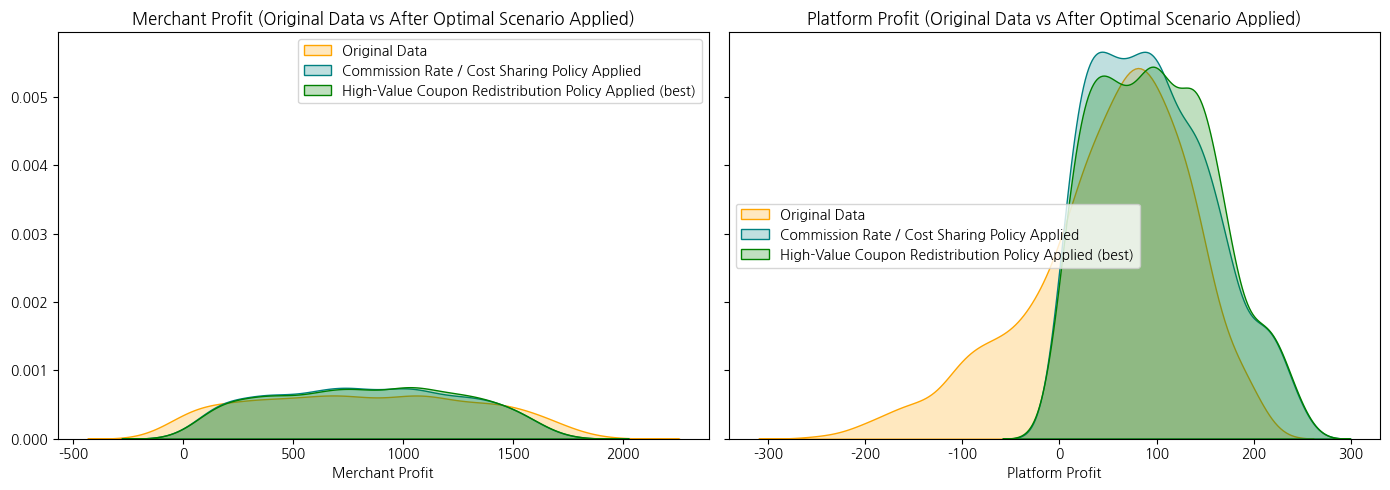

In [72]:
# Platform profit distribution comparison
fig, axs = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Right: df (before policy applied) vs df_best (after policy applied)
sns.kdeplot(df['Platform Profit'], ax=axs[1], label='Original Data',color='orange', fill=True)
sns.kdeplot(df_final['F Platform Profit'], ax=axs[1], label='Commission Rate / Cost Sharing Policy Applied', color='teal', fill=True)
sns.kdeplot(df_best['F Platform Profit'], ax=axs[1], label='High-Value Coupon Redistribution Policy Applied (best)', color='green', fill=True)
#sns.kdeplot(df_worst['F Platform Profit'], ax=axs[1], label='High-Value Coupon Redistribution Policy Applied (worst)', color='salmon', fill=True)
axs[1].set_title('Platform Profit (Original Data vs After Optimal Scenario Applied)')
axs[1].set_xlabel('Platform Profit')
axs[1].set_ylabel('Density')
axs[1].legend()

# Left: df (before policy applied) vs df_best (after policy applied)
sns.kdeplot(df['Merchant Profit'], ax=axs[0], label='Original Data', color='orange', fill=True)
sns.kdeplot(df_final['F Merchant Profit'], ax=axs[0], label='Commission Rate / Cost Sharing Policy Applied', color='teal', fill=True)
sns.kdeplot(df_best['F Merchant Profit'], ax=axs[0], label='High-Value Coupon Redistribution Policy Applied (best)', color='green', fill=True)
#sns.kdeplot(df_worst['F Merchant Profit'], ax=axs[0], label='High-Value Coupon Redistribution Policy Applied (worst)', color='salmon', fill=True)
axs[0].set_title('Merchant Profit (Original Data vs After Optimal Scenario Applied)')
axs[0].set_xlabel('Merchant Profit')
axs[0].set_ylabel('')
axs[0].legend()

plt.tight_layout()
plt.show()

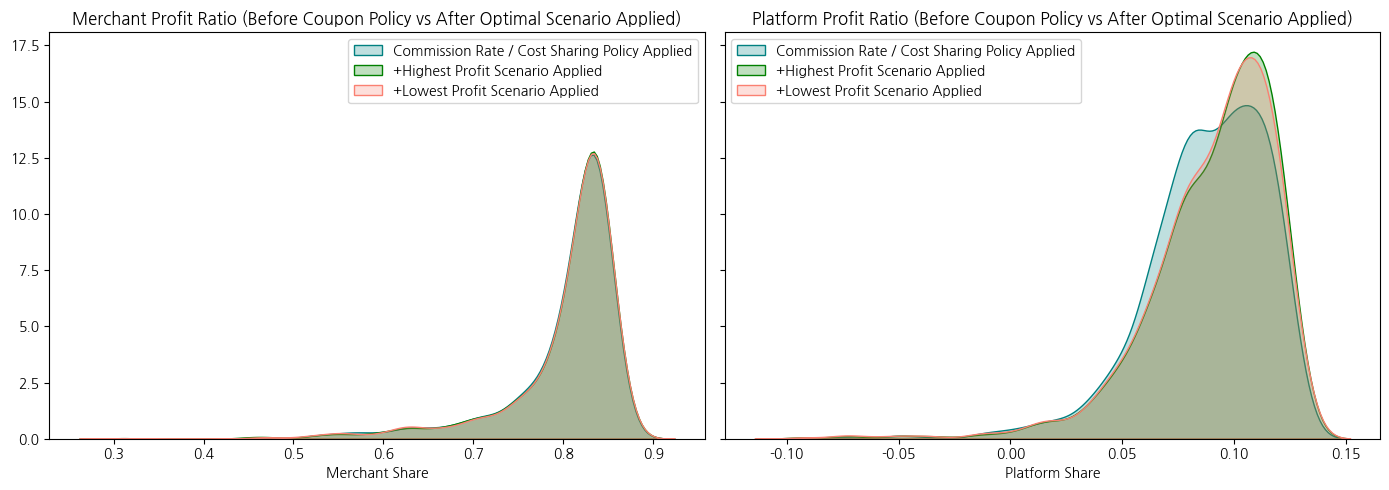

In [73]:
# Platform profit distribution comparison
fig, axs = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Left: df (before policy applied) vs df_best (after policy applied)
#sns.kdeplot(df['Platform Share'], ax=axs[1], label='Original Data',color='orange', fill=True)
sns.kdeplot(df_final['F Platform Share'], ax=axs[1], label='Commission Rate / Cost Sharing Policy Applied', color='teal', fill=True)
sns.kdeplot(df_best['F Platform Share'], ax=axs[1], label='+Highest Profit Scenario Applied', color='green', fill=True)
sns.kdeplot(df_worst['F Platform Share'], ax=axs[1], label='+Lowest Profit Scenario Applied', color='salmon', fill=True)
axs[1].set_title('Platform Profit Ratio (Before Coupon Policy vs After Optimal Scenario Applied)')
axs[1].set_xlabel('Platform Share')
axs[1].set_ylabel('Density')
axs[1].legend()

# Right: df (before policy applied) vs df_best (after policy applied)
#sns.kdeplot(df['Merchant Share'], ax=axs[0], label='Original Data', color='orange', fill=True)
sns.kdeplot(df_final['F Merchant Share'], ax=axs[0], label='Commission Rate / Cost Sharing Policy Applied', color='teal', fill=True)
sns.kdeplot(df_best['F Merchant Share'], ax=axs[0], label='+Highest Profit Scenario Applied', color='green', fill=True)
sns.kdeplot(df_worst['F Merchant Share'], ax=axs[0], label='+Lowest Profit Scenario Applied', color='salmon', fill=True)
axs[0].set_title('Merchant Profit Ratio (Before Coupon Policy vs After Optimal Scenario Applied)')
axs[0].set_xlabel('Merchant Share')
axs[0].set_ylabel('')
axs[0].legend()

plt.tight_layout()
plt.show()

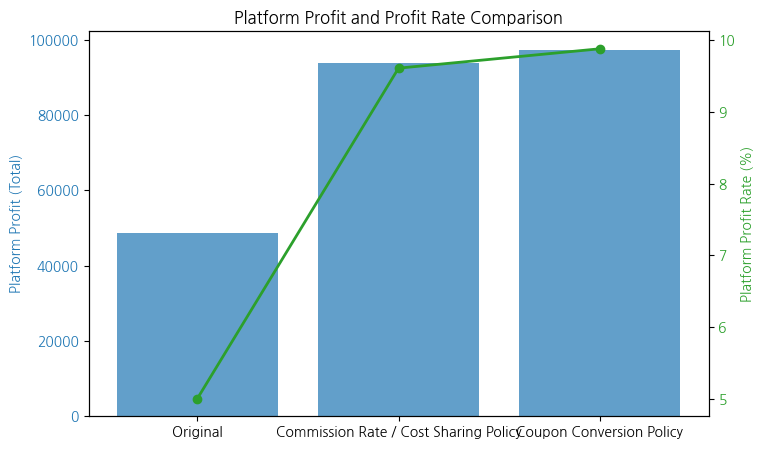

In [74]:
# 1️⃣ Prepare data
summary = pd.DataFrame({
    'Scenario': ['Original', 'Commission Rate / Cost Sharing Policy', 'Coupon Conversion Policy'],
    'Platform_Profit_Total': [
        df['Platform Profit'].sum(),
        df_final['F Platform Profit'].sum(),
        df_best['F Platform Profit'].sum()
    ],
    'Platform_Share_Percent': [
        df['Platform Profit'].sum() / df['Real Order Value'].sum() * 100,
        df_final['F Platform Profit'].sum() / df_final['Real Order Value'].sum() * 100,
        df_best['F Platform Profit'].sum() / df_best['Real Order Value'].sum() * 100
    ],
    'Merchant_Share_Percent': [
        df['Merchant Profit'].sum() / df['Real Order Value'].sum() * 100,
        df_final['F Merchant Profit'].sum() / df_final['Real Order Value'].sum() * 100,
        df_best['F Merchant Profit'].sum() / df_best['Real Order Value'].sum() * 100
    ],

    'Platform_Order_Total': [
        df_final['Order Value'].sum(),
        df_best['Order Value'].sum(),
        df_worst['Order Value'].sum()
    ],
    'Merchant_Profit_Total': [
        df_final['F Merchant Share'].sum(),
        df_best['F Merchant Share'].sum(),
        df_worst['F Merchant Share'].sum()
    ],
    'Merchant_Order_Total': [
        df_final['Order Value'].sum(),
        df_best['Order Value'].sum(),
        df_worst['Order Value'].sum()
    ]
})

# 2️⃣ Bar chart: platform profit and profit rate
fig, ax1 = plt.subplots(figsize=(8,5))

color1 = 'tab:blue'
ax1.bar(summary['Scenario'], summary['Platform_Profit_Total'], color=color1, alpha=0.7)
ax1.set_ylabel('Platform Profit (Total)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Secondary Y-axis: profit rate
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.plot(summary['Scenario'], summary['Platform_Share_Percent'], color=color2, marker='o', linewidth=2)
ax2.set_ylabel('Platform Profit Rate (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Platform Profit and Profit Rate Comparison')
plt.show()

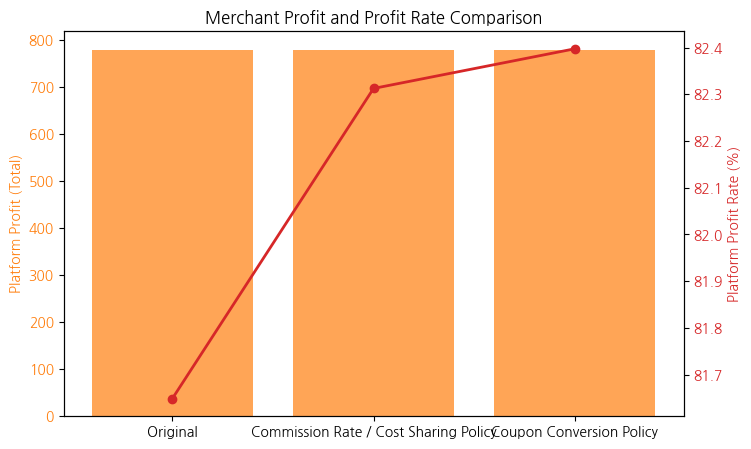

In [75]:
# 2️⃣ Bar chart: merchant profit and profit rate
fig, ax1 = plt.subplots(figsize=(8,5))

color1 = 'tab:orange'
ax1.bar(summary['Scenario'], summary['Merchant_Profit_Total'], color=color1, alpha=0.7)
ax1.set_ylabel('Platform Profit (Total)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Secondary Y-axis: profit rate
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(summary['Scenario'], summary['Merchant_Share_Percent'], color=color2, marker='o', linewidth=2)
ax2.set_ylabel('Platform Profit Rate (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Merchant Profit and Profit Rate Comparison')
plt.show()

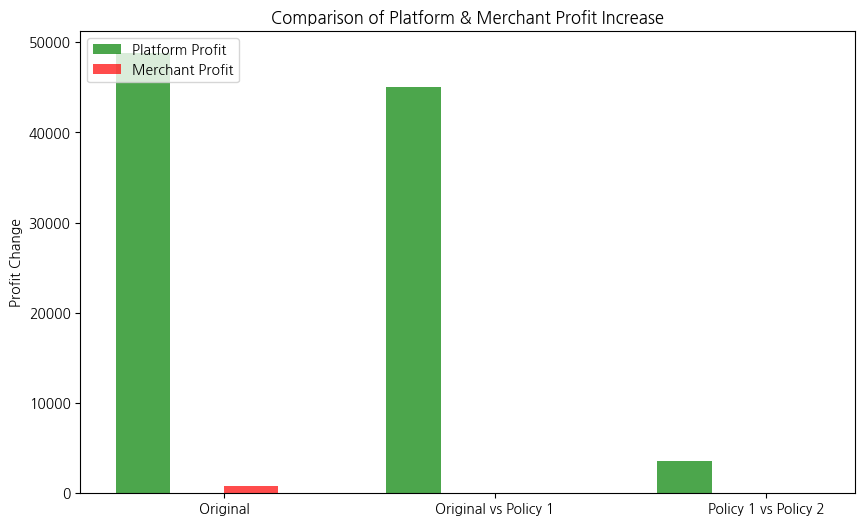

In [76]:
fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(3)
width = 0.2  # bar width

# -----------------------------
# 1) Platform
# -----------------------------
platform_profit = [
    summary.loc[0, 'Platform_Profit_Total'],
    summary.loc[1, 'Platform_Profit_Total'] - summary.loc[0, 'Platform_Profit_Total'],
    summary.loc[2, 'Platform_Profit_Total'] - summary.loc[1, 'Platform_Profit_Total']
]

# -----------------------------
# 2) Merchant
# -----------------------------
merchant_profit = [
    summary.loc[0, 'Merchant_Profit_Total'],
    summary.loc[1, 'Merchant_Profit_Total'] - summary.loc[0, 'Merchant_Profit_Total'],
    summary.loc[2, 'Merchant_Profit_Total'] - summary.loc[1, 'Merchant_Profit_Total']
]

# -----------------------------
# Draw bars
# -----------------------------
ax.bar(x - 1.5*width, platform_profit, width, color='green', alpha=0.7, label='Platform Profit')
ax.bar(x + 0.5*width, merchant_profit, width, color='red', alpha=0.7, label='Merchant Profit')

# -----------------------------
# x-axis labels
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(['Original', 'Original vs Policy 1', 'Policy 1 vs Policy 2'])

ax.set_ylabel('Profit Change')
ax.set_title('Comparison of Platform & Merchant Profit Increase')

ax.legend(loc='upper left')
plt.show()

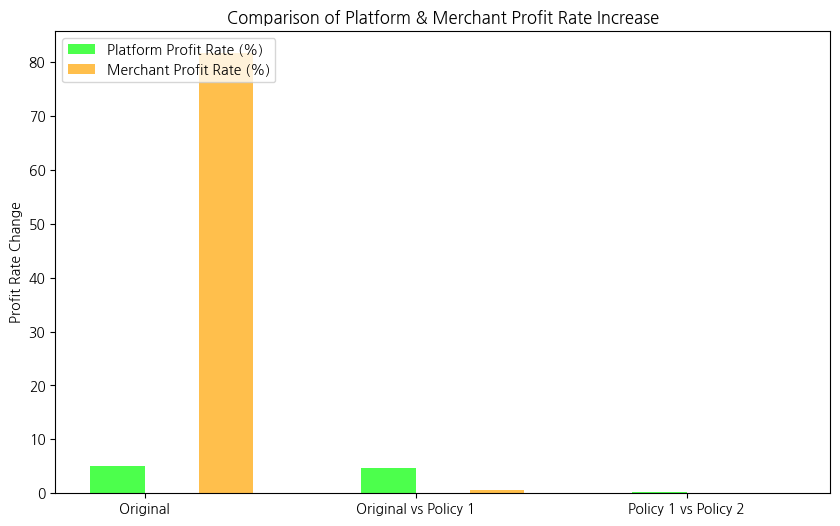

In [77]:
fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(3)
width = 0.2  # bar width

# -----------------------------
# 1) Platform
# -----------------------------

platform_profit_rate = [
    (summary.loc[0, 'Platform_Share_Percent']),
    (summary.loc[1, 'Platform_Share_Percent']- summary.loc[0, 'Platform_Share_Percent']),
    (summary.loc[2, 'Platform_Share_Percent'] - summary.loc[1, 'Platform_Share_Percent'])
]

# -----------------------------
# 2) Merchant
# -----------------------------

merchant_profit_rate = [
    (summary.loc[0, 'Merchant_Share_Percent']),
    (summary.loc[1, 'Merchant_Share_Percent']- summary.loc[0, 'Merchant_Share_Percent']),
    (summary.loc[2, 'Merchant_Share_Percent'] - summary.loc[1, 'Merchant_Share_Percent'])
]

# -----------------------------
# Draw bars
# -----------------------------

ax.bar(x - 0.5*width, platform_profit_rate, width, color='lime', alpha=0.7, label='Platform Profit Rate (%)')
ax.bar(x + 1.5*width, merchant_profit_rate, width, color='orange', alpha=0.7, label='Merchant Profit Rate (%)')

# -----------------------------
# x-axis labels
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(['Original', 'Original vs Policy 1', 'Policy 1 vs Policy 2'])

ax.set_ylabel('Profit Rate Change')
ax.set_title('Comparison of Platform & Merchant Profit Rate Increase')

ax.legend(loc='upper left')
plt.show()

In [78]:
original = compute_grouped_profit_summary(df)
final = compute_grouped_profit_summary(df_final)
best = compute_grouped_profit_summary(df_best)
worst = compute_grouped_profit_summary(df_worst)

In [81]:
def visualize_coupon_performance(df, group_col='Discounts and Offers',
                                 ratio_col='Ratio (%)', weighted_profit_col='F Platform Profit weighted mean',
                                 title='Order Ratio & Platform Share by Coupon'):
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10,6))

    # x축 문자열 변환
    df[group_col] = df[group_col].astype(str)

    # 막대그래프: 주문 비중
    sns.barplot(
        data=df,
        x=group_col,
        y=ratio_col,
        palette='Blues_d',
        ax=ax1
    )
    ax1.set_ylabel('Order Ratio (%)', color='blue')
    ax1.set_xlabel('Coupon Type')
    ax1.set_title(title)

    # 두 번째 y축: 가중평균 수익률
    ax2 = ax1.twinx()
    sns.lineplot(
        data=df,
        x=group_col,
        y=weighted_profit_col,
        marker='o',
        color='red',
        ax=ax2
    )
    ax2.set_ylabel('Avg Platform Share', color='red')

    # x축 라벨 회전
    plt.xticks(rotation=45)

    plt.show()


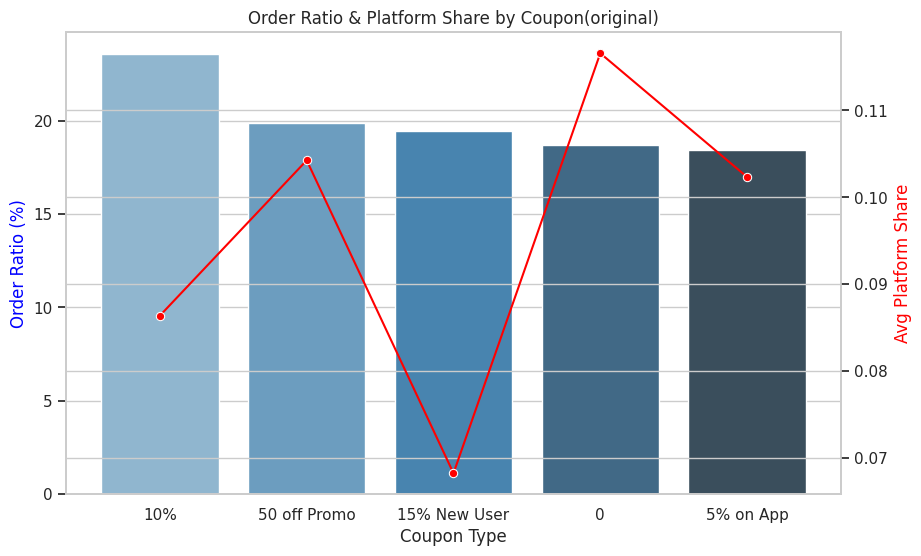

In [82]:
visualize_coupon_performance(original,title='Order Ratio & Platform Share by Coupon(original)')

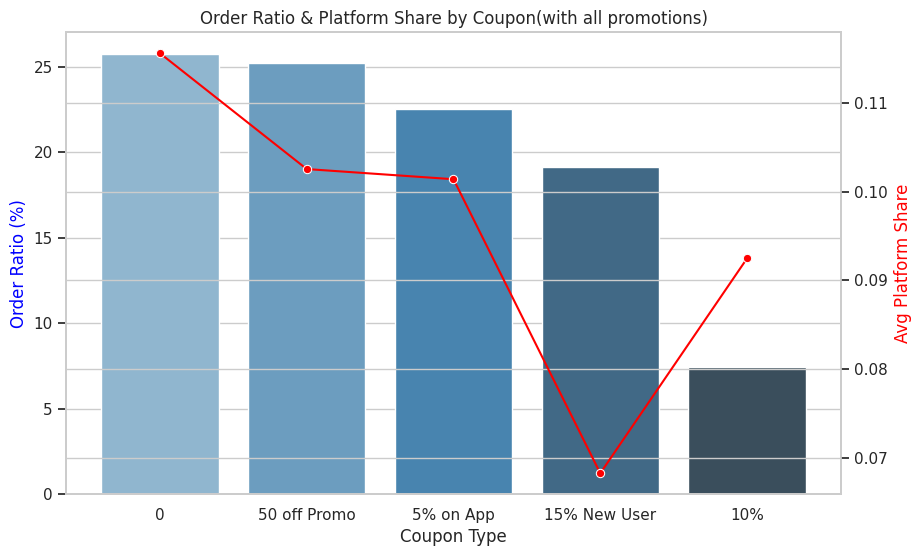

In [83]:
visualize_coupon_performance(best, title='Order Ratio & Platform Share by Coupon(with all promotions)')

# **5. Final Conclusion**

## Key Findings

* When applying the **new commission rates**, **delivery fee / discount cost-sharing structure**, and **differentiated coupon issuance policy**, the **platform profit margin improved by +4.88%p**, and **platform profit increased by +99.61%**.
* This approach **maximizes platform profit while avoiding a decline in merchant profit compared to the baseline**.
* The **largest potential risk** is customer churn among **non-VIP customers excluded from benefits**. This risk can be **hedged by expanding the issuance of low-discount coupons**.

---

## Strategic Recommendations

### 1. Tiered Commission Rates by Merchant

* Apply **differentiated commission rates by merchant sales level**
* Divide merchants into **three sales tiers**
* Apply commission rates proportionally at **11%, 12%, and 13%**

### 2. Cost-Sharing Structure

* Set the **platform : merchant cost-sharing ratio** at **3:7**

### 3. 15% New User Coupon Policy

* Limit the **15% New User coupon** to **one-time issuance only**

### 4. 10% Coupon Policy

* Restrict the **10% coupon** to customers whose **previous month’s order value was at least 1,539.61 rupees**
* This corresponds to the **top 26.85% of customers**

---

## Expected Impact

### Higher Profitability

* Because commission rates can be set **in proportion to order value**, the platform can secure **higher commission revenue**, leading to an **increase in overall profit margin**

### Lower Burden for Both Sides

* Even under the **3:7 cost-sharing model**, merchants also achieve **higher profit than before**
* This minimizes the financial burden for **both merchants and the platform**

### More Efficient New User Promotion

* Limiting the **15% coupon to one use** preserves its **new customer acquisition effect**
* At the same time, it helps prevent **excessive discount spending**

### Stronger Customer Loyalty with Better ROI

* Issuing the **10% coupon only to VIP customers** helps strengthen **customer loyalty**
* It also improves **sales performance relative to promotional cost**

---

## Overall Recommendation

This strategy provides a more sustainable profit structure by balancing:

* **platform profit maximization**
* **merchant profitability protection**
* **promotion cost efficiency**
* **customer retention through selective incentives**

In other words, it is a **profitability-focused optimization strategy** that improves financial outcomes while keeping stakeholder burden under control.
